## Welcome
Currently using a conda environment based on lukas_fysstk.yaml.

This jupyter notebook contains all the calculations and plotting for the figures of our first project report for FYSSTK-4155.
Authors: Esme Hookham, Lukas Monrad-Krohn and Andrea Rosendahl

In [1]:
### imports
# basics
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatter
import matplotlib

# scikit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample


import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

from IPython.display import Image

### recurring functions and helpers
#Function for OLS through SVD
def ols(X, y):
    """Ordinary least squares through the SVD.
       provided by: https://github.com/EducationalMaterialUiO/MachineLearningUiO/"""
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (U.T @ y / s)

def runge(x):
    """Runge function, given in task description."""
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    """creates design matrix for polynomial regression of given degree and intercept option.
       given in task description."""
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

def MSE(y_data, y_model):
    """from Tuesday lecture week 35"""
    return np.mean((y_data - y_model) ** 2)

def R2(y_data, y_model):
    """from Tuesday lecture week 35"""
    return 1.0 - np.sum((y_data - y_model) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

# Functions from exercises
def cost(theta, X, y, lam=0.0):
    #if lambda == 0, this is OLS, otherwise Ridge
    return jnp.mean((y - X @ theta)**2) + lam * jnp.sum(theta**2)

def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    """Eigenvalues of the Hessian (2/n) X^T X + 2 lambda I, Eqs. (4.14) and (4.17)."""
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lam):
    return jnp.mean((y - X @ theta)**2) + lam * jnp.sum(theta**2)

def cost_lasso(theta, X, y, lam):
    return jnp.mean((y - X @ theta)**2) + lam * jnp.sum(jnp.abs(theta))



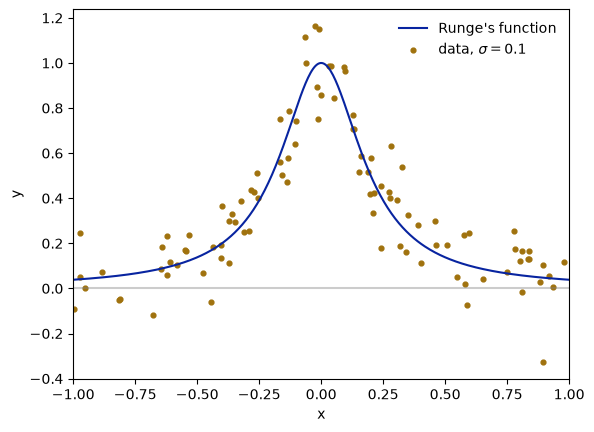

In [2]:
### Generate data and create quicklook
def generate_data(n=100, sigma=0.1, seed=2026):
    rng = np.random.default_rng(seed)     
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    return x, y, n, sigma

x, y, n, sigma = generate_data()

train_color = "#32A911"
test_color = "#048582"

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#0824A0", label="Runge's function")
plt.scatter(x, y, s=12, color="#A0720E", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.xlim(-1,1)
plt.plot([-1,1], [0,0], color='grey', linestyle='-', alpha=0.4)
plt.show()

## Part a): Ordinary Least Squares (OLS) for the Runge function

C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\4271255037.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[0].plot(xx,mse_train,"b*-",label="Train", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\4271255037.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r*-" (-> color='r'). The keyword argument will take precedence.
  ax[0].plot(xx,mse_test,"r*-",label="Test", color=test_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\4271255037.py:61: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[1].plot(xx,r2_train,"b*-",label="Train", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\4271255037.py:62: UserWarning: color is redundantly defined by the 'co

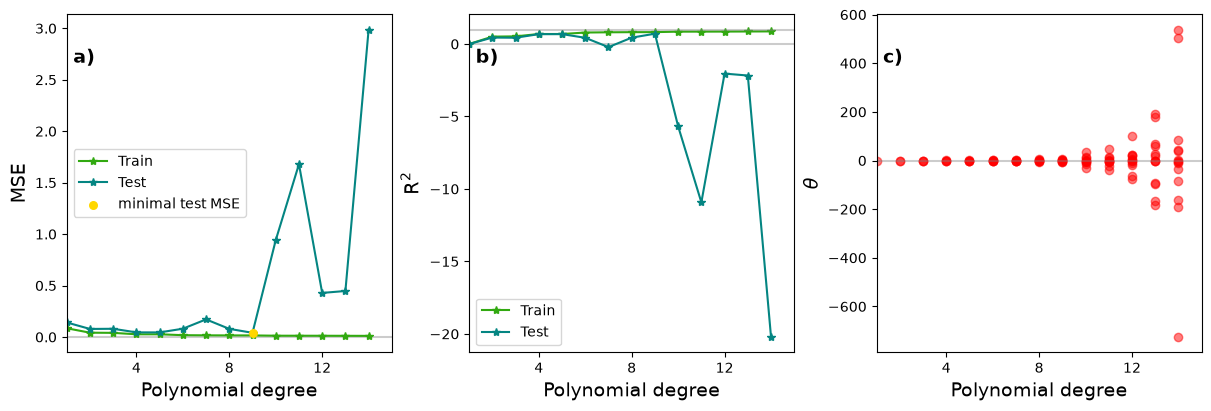

In [3]:
# Splitting data into test and train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=2026)

### collector function
def prepare_design_matrix(x_train, x_test, y_train, y_test, degree=5, intercept=True):
    """prepares design matrix and scales data"""
    # create design matrix
    X_train = design_matrix(x_train, degree=degree, intercept=intercept)
    X_test = design_matrix(x_test, degree=degree, intercept=intercept)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm

#Adding a model to perform OLS for polynomials up to degree 15
mse_train = []
mse_test = []
r2_train = []
r2_test = []
save_theta = []
for d in range(1,15):
    #Design matrix on the training data:
    X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    #calculate OLS theta
    # theta = ols(X_train,y_train)
    theta = closed_form(X_train,y_train)
    save_theta.append(theta)

    #Calculate the MSE:
    mse_train.append(mean_squared_error(y_train, X_train @ theta))
    mse_test.append(mean_squared_error(y_test,  X_test @ theta))
    r2_train.append(r2_score(y_train, X_train @ theta))
    r2_test.append(r2_score(y_test,  X_test @ theta))


#Plotting the MSE as a function of polynomial degree
xx = np.linspace(1,14,14)

fig, ax = plt.subplots(1,3,figsize=(12,4), constrained_layout=True)

for a in ax:
    # a.grid()    
    a.set_xticks(np.arange(0,16,4))
    a.set_xlim(1,15)
    # a.set_yscale('log')
    a.hlines(0,16,0, color='grey', alpha=0.4)


ax[0].plot(xx,mse_train,"b*-",label="Train", color=train_color)
ax[0].plot(xx,mse_test,"r*-",label="Test", color=test_color)
ax[0].set_ylabel("MSE", fontsize=14)
ax[0].set_xlabel("Polynomial degree", fontsize=14)
ax[0].scatter(xx[np.argmin(mse_test)], np.min(mse_test), color='gold', marker='o', s=30, zorder=5, label='minimal test MSE')
ax[0].legend()
ax[0].text(0.02, 0.9, 'a)', transform=ax[0].transAxes, fontsize=14, fontweight="bold", va="top", ha="left")

ax[1].plot(xx,r2_train,"b*-",label="Train", color=train_color)
ax[1].plot(xx,r2_test,"r*-",label="Test", color=test_color)
ax[1].set_ylabel("R$^2$", fontsize=14)
ax[1].set_xlabel("Polynomial degree", fontsize=14)
ax[1].legend()
ax[1].text(0.02, 0.9, 'b)', transform=ax[1].transAxes, fontsize=14, fontweight="bold", va="top", ha="left")
ax[1].hlines(1,16,0, color='grey', alpha=0.4)
# ax[1].set_ylim([1e-9, 1e0])

for i in range(len(save_theta)):
    ax[2].scatter(np.full(i+1, xx[i]), save_theta[i], color='r', alpha=0.5)
# ax[2].plot(xx,save_theta,"r*-",label="Test")
ax[2].set_ylabel(r"$\theta$", fontsize=14)
ax[2].set_xlabel("Polynomial degree", fontsize=14)
ax[2].text(0.02, 0.9, 'c)', transform=ax[2].transAxes, fontsize=14, fontweight="bold", va="top", ha="left")



plt.show()


## Part b): Adding Ridge regression for the Runge function

Polynomial degree: 1
Minimum MSE is  0.0852454331582845 at lambda = 2.5118864315095823e-07 for training data
Minimum MSE is  0.1408697620662985 at lambda = 10000.0 for test data
Polynomial degree: 2
Minimum MSE is  0.0419864756226363 at lambda = 2.511886431509582e-08 for training data
Minimum MSE is  0.07832073165244044 at lambda = 1e-08 for test data
Polynomial degree: 3
Minimum MSE is  0.0403968803604171 at lambda = 6.30957344480193e-08 for training data
Minimum MSE is  0.0798943307575858 at lambda = 1.5848931924611174 for test data
Polynomial degree: 4
Minimum MSE is  0.026497232884738663 at lambda = 1e-08 for training data
Minimum MSE is  0.04509426766896332 at lambda = 1e-08 for test data
Polynomial degree: 5
Minimum MSE is  0.026493143402373014 at lambda = 1e-08 for training data
Minimum MSE is  0.044767790791748426 at lambda = 1e-08 for test data
Polynomial degree: 6
Minimum MSE is  0.017829076450046364 at lambda = 1e-08 for training data
Minimum MSE is  0.04047207755781056 at l

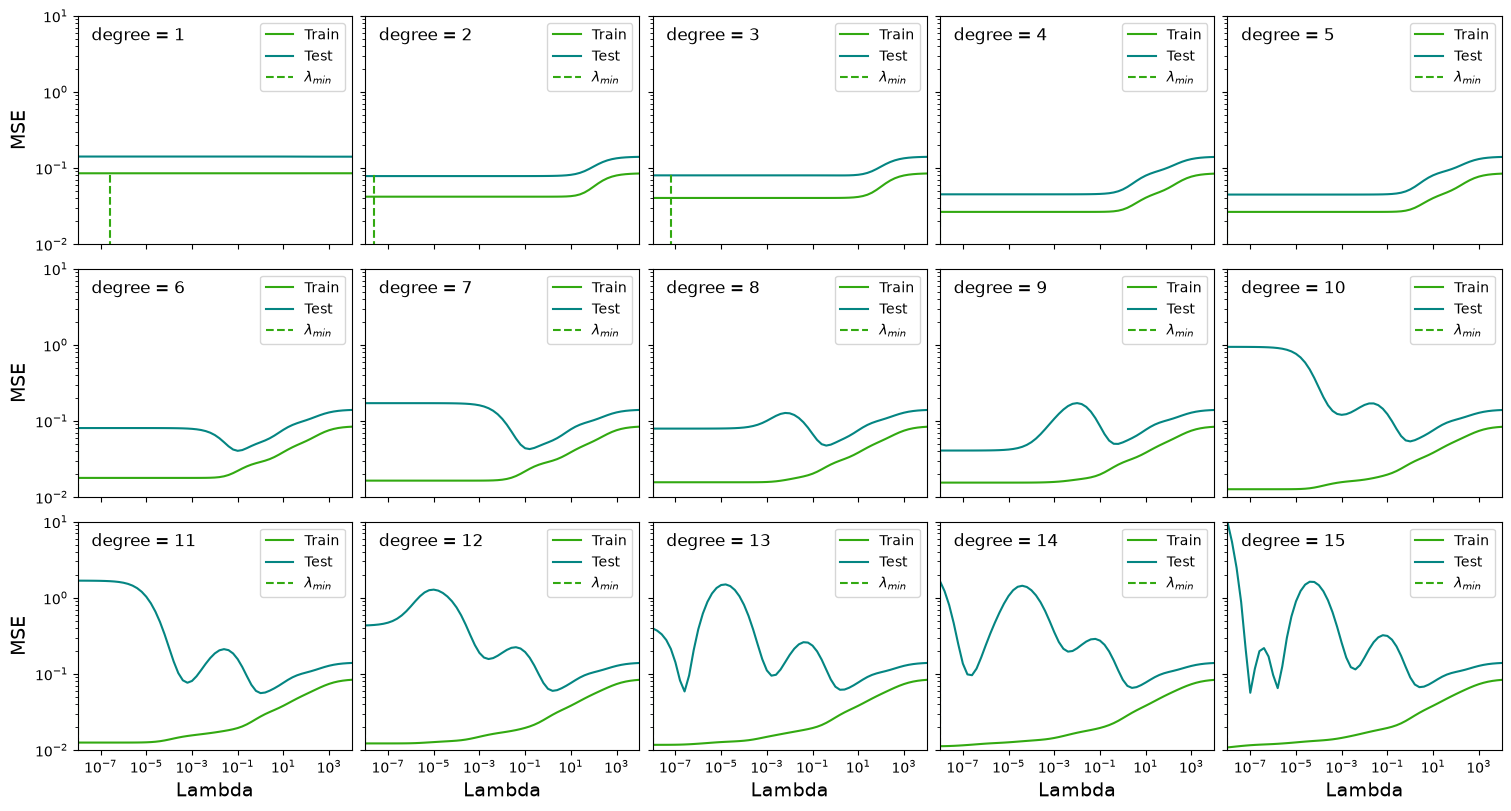

Polynomial degree: 2
Minimum MSE is  0.0419864756226363 at lambda = 2.511886431509582e-08 for training data
Minimum MSE is  0.07832073165244044 at lambda = 1e-08 for test data
Polynomial degree: 5
Minimum MSE is  0.026493143402373014 at lambda = 1e-08 for training data
Minimum MSE is  0.044767790791748426 at lambda = 1e-08 for test data
Polynomial degree: 6
Minimum MSE is  0.017829076450046364 at lambda = 1e-08 for training data
Minimum MSE is  0.04047207755781056 at lambda = 0.1 for test data
Polynomial degree: 15
Minimum MSE is  0.010797727052551677 at lambda = 1e-08 for training data
Minimum MSE is  0.056442377861310566 at lambda = 1e-07 for test data


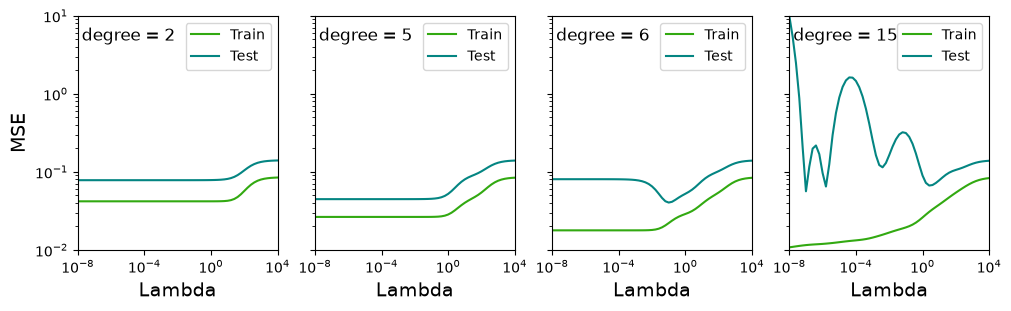

In [4]:
#Adding a model to perform OLS for polynomials up to degree 15
degs = np.arange(1,16)
fig = plt.figure(figsize=(15,8), constrained_layout=True)
axes=[]
# plot all of the panels here first
for d in degs:
    ax = fig.add_subplot(3,5,d, sharex=axes[0] if axes else None, sharey=axes[0] if axes else None)
    axes.append(ax)
    #Design matrix on the training data:
    # X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    X_train = design_matrix(x_train, degree=d, intercept=False)
    X_test = design_matrix(x_test, degree=d, intercept=False)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)

    #Loop through different lambdas and calculate the Ridge regression and MSE
    lambdas = np.logspace(-8, 4, 61)
    mse_train = []
    mse_test = []
    for l in lambdas:
        #Theta from Ridge
        theta = Ridge(alpha=l, fit_intercept=False).fit(X_train_norm, y_train_norm).coef_
        #MSE for train and test data
        mse_train.append(mean_squared_error(y_train_norm, np.mean(y_test) + X_train_norm @ theta))
        mse_test.append(mean_squared_error(y_test_norm,  np.mean(y_test) + X_test_norm @ theta))


    #Plot the results
    ax.plot(lambdas,mse_train,label="Train", color=train_color)
    ax.plot(lambdas,mse_test,label="Test", color=test_color)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("MSE", fontsize=14)
    ax.set_xlabel("Lambda", fontsize=14)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xlim(1e-8, 1e4)
    ax.vlines(lambdas[np.argmin(mse_train)],ymin=0,ymax=np.max(mse_train),linestyle="--",  label=r'$\lambda_{min}$', color=train_color)
    ax.legend()
    ax.label_outer()
    ax.text(0.05, 0.95, f"degree = {d}", transform=ax.transAxes, ha="left", va="top", fontsize=12)


    #Finding the minimum MSE and at what lambda
    print(f"Polynomial degree: {d}")
    print("Minimum MSE is ",np.min(mse_train), "at lambda =", lambdas[np.argmin(mse_train)], "for training data")
    print("Minimum MSE is ",np.min(mse_test), "at lambda =", lambdas[np.argmin(mse_test)], "for test data")
plt.show()

# not plot selected subset of panels
fig = plt.figure(figsize=(10,3), constrained_layout=True)
count=0
axes = []
for d in [2,5,6,15]:
    count+=1
    ax = fig.add_subplot(1,4,count, sharex=axes[0] if axes else None, sharey=axes[0] if axes else None)
    axes.append(ax)
    #Design matrix on the training data:
    # X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    X_train = design_matrix(x_train, degree=d, intercept=False)
    X_test = design_matrix(x_test, degree=d, intercept=False)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)

    #Loop through different lambdas and calculate the Ridge regression and MSE
    lambdas = np.logspace(-8, 4, 61)
    mse_train = []
    mse_test = []
    for l in lambdas:
        #Theta from Ridge
        theta = Ridge(alpha=l, fit_intercept=False).fit(X_train_norm, y_train_norm).coef_
        #MSE for train and test data
        mse_train.append(mean_squared_error(y_train_norm, np.mean(y_test) + X_train_norm @ theta))
        mse_test.append(mean_squared_error(y_test_norm,  np.mean(y_test) + X_test_norm @ theta))


    #Plot the results
    ax.plot(lambdas,mse_train,label="Train", color=train_color)
    ax.plot(lambdas,mse_test,label="Test", color=test_color)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("MSE", fontsize=14)
    ax.set_xlabel("Lambda", fontsize=14)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xlim(1e-8, 1e4)
    # ax.vlines(lambdas[np.argmin(mse_train)],ymin=0,ymax=np.max(mse_train),linestyle="--", label=r'$\lambda_{min}$', color=train_color)    
    ax.legend()
    ax.label_outer()
    ax.text(0.02, 0.95, f"degree = {d}", transform=ax.transAxes, ha="left", va="top", fontsize=12)

    #Finding the minimum MSE and at what lambda
    print(f"Polynomial degree: {d}")
    print("Minimum MSE is ",np.min(mse_train), "at lambda =", lambdas[np.argmin(mse_train)], "for training data")
    print("Minimum MSE is ",np.min(mse_test), "at lambda =", lambdas[np.argmin(mse_test)], "for test data")
plt.show()

### Part c): The bias-variance tradeoff and the bootstrap

C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\762280785.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[i].plot(xx,mse_train,"b*-",label="Train", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\762280785.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r*-" (-> color='r'). The keyword argument will take precedence.
  ax[i].plot(xx,mse_test,"r*-",label="Test", color=test_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\762280785.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[i].plot(xx,mse_train,"b*-",label="Train", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\762280785.py:29: UserWarning: color is redundantly defined by the 'color

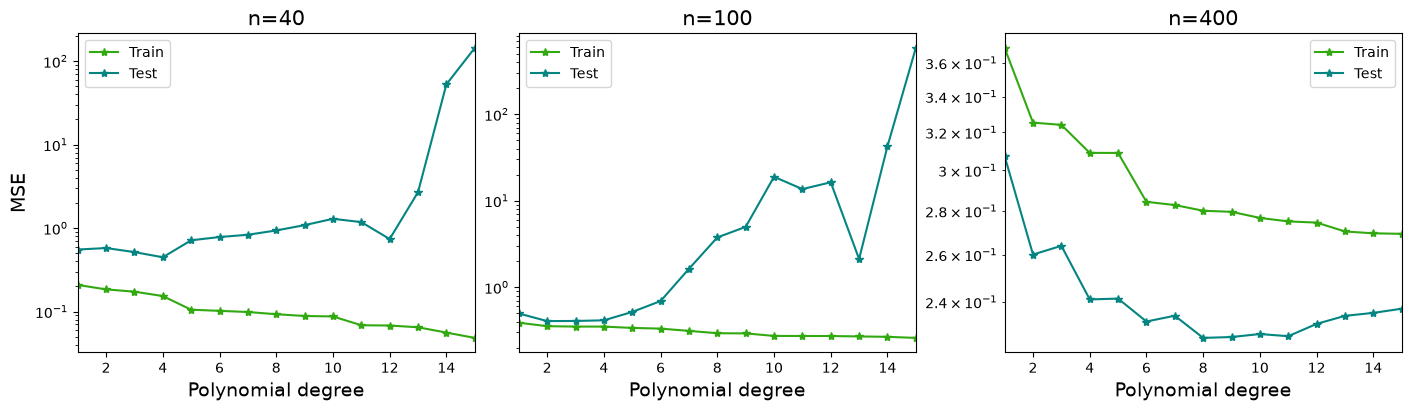

In [5]:
# Your code for part c) heret
### Inspired by figure 2.11 in Hastie et al., 2009

max_deg = 15
fig, ax = plt.subplots(1,3,figsize=(14,4), sharey=False, constrained_layout=True)
for n, i in zip((40, 100, 400), (0,1,2)):
    # get some new data (but different names to not overwrite the ones used consistently)
    x_c, y_c, n_c, sigma_c = generate_data(n=n, sigma=0.5)
    x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_c, y_c, test_size=0.3,random_state=2026)

    #Adding a model to perform OLS for polynomials up to degree 15
    mse_train = []
    mse_test = []
    for d in range(1,max_deg+1):
        X_train_c, X_test_c, y_train_c, y_test_c = prepare_design_matrix(x_train_c, x_test_c, y_train_c, y_test_c, degree=d, intercept=False)
        
        #calculate OLS theta
        theta = ols(X_train_c,y_train_c)

        #Calculate the MSE:
        mse_train.append(mean_squared_error(y_train_c, X_train_c @ theta))
        mse_test.append(mean_squared_error(y_test_c,  X_test_c @ theta))


    #Plotting the MSE as a function of polynomial degree
    xx = np.linspace(1,max_deg,max_deg)

    ax[i].plot(xx,mse_train,"b*-",label="Train", color=train_color)
    ax[i].plot(xx,mse_test,"r*-",label="Test", color=test_color)
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree", fontsize=14)
    ax[i].set_title(f"n={n}", fontsize=15)
    ax[i].legend()
    ax[i].set_xlim(1,15)
ax[0].set_ylabel("MSE", fontsize=14)


plt.show()

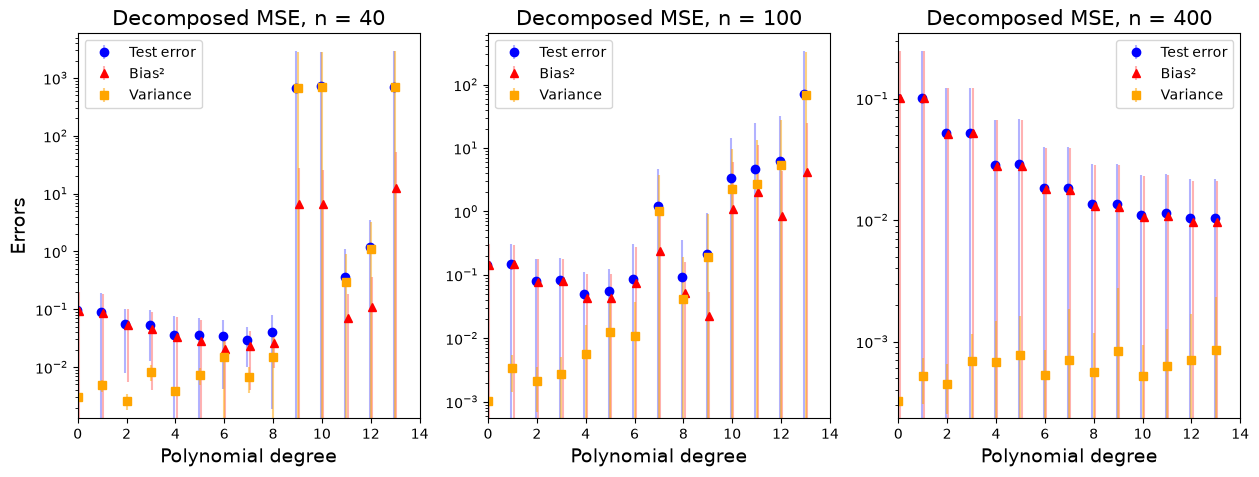

In [6]:
n_bootstraps = 100 #100 resamples of training data
degree_max = 14 #13 + 1

def bootstrap_polynomial(n, degree_max, sigma=0.1, seed=2026, n_bootstraps=n_bootstraps):
    x, y, _, _ = generate_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=seed)

    x_train = x_train.reshape(-1, 1)
    x_test = x_test.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    error, error_std = np.zeros(degree_max), np.zeros(degree_max)
    bias, bias_std = np.zeros(degree_max), np.zeros(degree_max)
    variance, variance_std = np.zeros(degree_max), np.zeros(degree_max)

    for degree in range(degree_max):
        model = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression(fit_intercept=False))
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

        error_std[degree] = np.std(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias_std[degree] = np.std((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance_std[degree] = np.std(np.var(y_pred, axis=1, keepdims=True))

    return error, bias, variance, error_std, bias_std, variance_std
    

fig, ax = plt.subplots(1,3,figsize=[15,5])
sp = 0 #What subplot / axis to plot

for n in (40, 100, 400): #40,100,400
    error, bias, variance, error_std, bias_std, variance_std = bootstrap_polynomial(n=n, degree_max=degree_max)

    #Plot results
    # ax[sp].plot(range(degree_max),error,"o-",color="blue",label="Test error")
    # ax[sp].plot(range(degree_max),bias,"o-",color="red", label="Bias²", alpha=1)
    # ax[sp].plot(range(degree_max),variance,"o-",color="orange",label="Variance")
    ax[sp].errorbar(np.arange(degree_max)-0.05, error, yerr = error_std, fmt='o', color="blue", label="Test error", ecolor=(0.0, 0.0, 1.0, 0.3))
    ax[sp].errorbar(np.arange(degree_max)+0.05, bias, yerr = bias_std, fmt='^', color="red", label="Bias²", ecolor=(1.0, 0.0, 0.0, 0.3))
    ax[sp].errorbar(range(degree_max), variance, yerr = variance_std, fmt='s', color="orange", label= "Variance", ecolor=(1.0, 0.6471, 0.0, 0.5))
    ax[sp].set_title(f"Decomposed MSE, n = {n}", fontsize=15)
    ax[sp].set_xlabel("Polynomial degree", fontsize=14)
    
    # ax[sp].set_ylim(1e-4,2e3)
    ax[sp].set_yscale("log")
    ax[sp].set_xlim(0,14)
    ax[sp].legend()
    sp += 1
ax[0].set_ylabel("Errors", fontsize=14)
plt.show()


In [7]:
#Replacing OLS by Ridge regression at fixed degree 12
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    error_std, bias_std, variance_std = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
        error_std[degree] = np.std(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias_std[degree] = np.std((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance_std[degree] = np.std(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance, error_std, bias_std, variance_std



degree_fixed = 12
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 40, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var, err_std, b2_std, var_std = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                                make_model=mk)
    
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")
    

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance
     OLS      0.0762      0.0284      0.0478
  0.0001      0.0338      0.0272      0.0067
     0.1      0.0289      0.0228      0.0060
      10      0.1020      0.0979      0.0041


## Part d): Cross-validation as a resampling technique

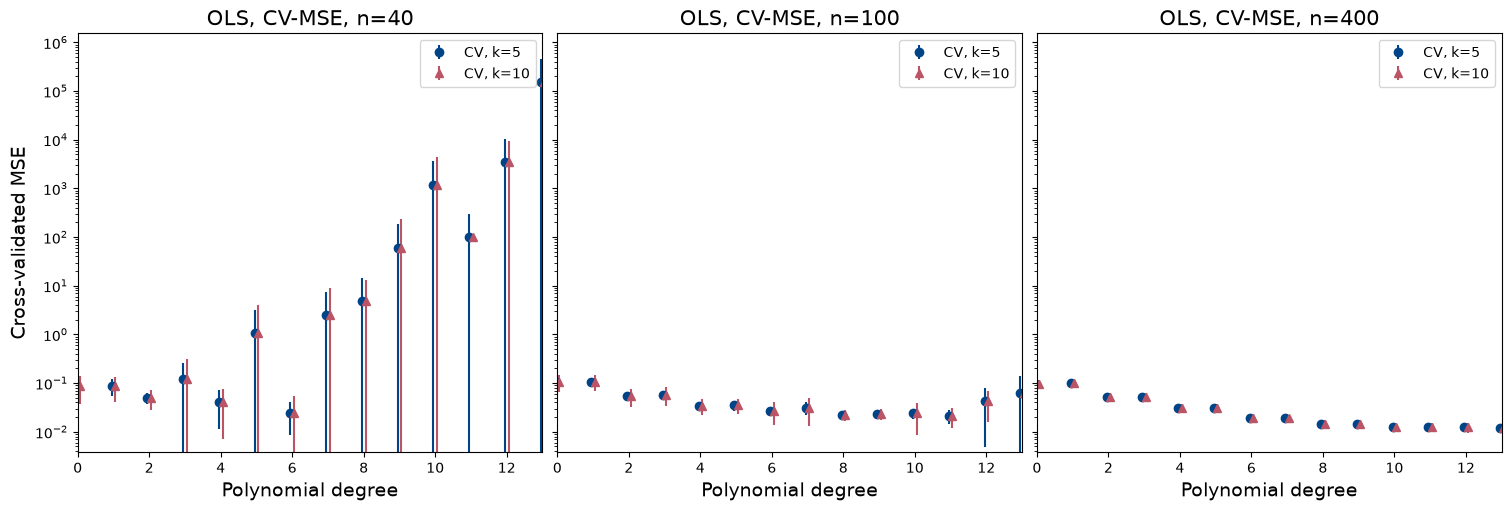

In [8]:
# Use the k-fold cross-validation functionality of Scikit-Learn (KFold together with cross_val_score,
# or cross_validate) and evaluate again the MSE function resulting from the test folds, for the
# OLS analysis of parts a) and c) as a function of the polynomial degree, 


def cv_mse_ols(x, y, degree_max, k, seed=2026):
    """k-fold CV MSE for OLS, as a function of polynomial degree."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mse_mean = np.zeros(degree_max)
    mse_std = np.zeros(degree_max)
    for degree in range(degree_max):
        pipe = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y, cv=kf,
                                   scoring="neg_mean_squared_error")
        mse_mean[degree] = scores.mean()
        mse_std[degree] = scores.std()
    return mse_mean, mse_std

# Same n-values as the bootstrap sweep in part c)
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, constrained_layout=True)

for i, n in enumerate((40, 100, 400)):
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5, mse_k5_std  = cv_mse_ols(x_cv, y_cv, degree_max, k=5)
    mse_k10, mse_k10_std = cv_mse_ols(x_cv, y_cv, degree_max, k=10)

    # ax[i].plot(range(degree_max), mse_k5,  "o-", color="#004488", label="CV, k=5")
    # ax[i].plot(range(degree_max), mse_k10, "o-", color="#BB5566", label="CV, k=10")
    ax[i].errorbar(np.arange(degree_max)-0.05, mse_k5, yerr = mse_k5_std, fmt='o', color="#004488", label="CV, k=5")
    ax[i].errorbar(np.arange(degree_max)+0.05, mse_k5, yerr = mse_k10_std, fmt='^', color="#BB5566", label="CV, k=10")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree", fontsize=14)
    ax[i].set_title(f"OLS, CV-MSE, n={n}", fontsize=15)
    ax[i].legend()
    ax[i].set_xlim(0,13)

ax[0].set_ylabel("Cross-validated MSE", fontsize=14)
plt.show()

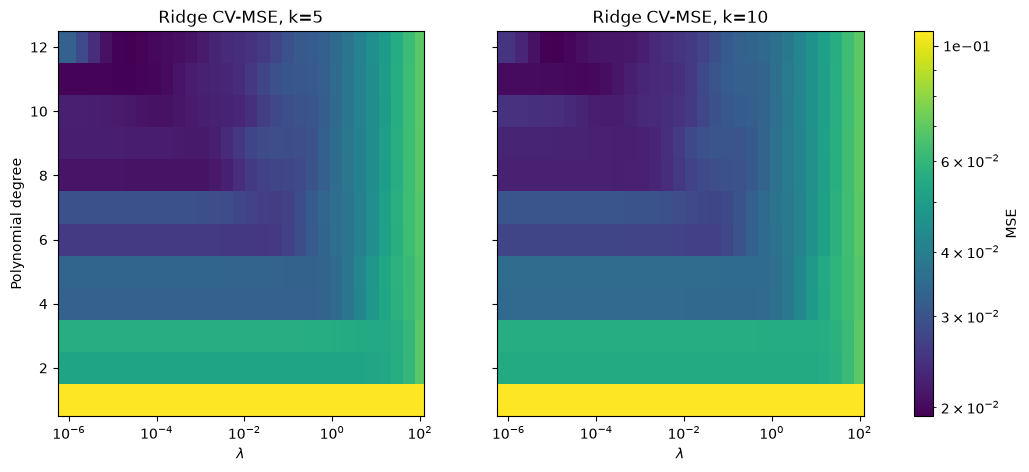

k=5: best degree=12, best lambda=2.395e-05, CV-MSE=0.02073
k=10: best degree=12, best lambda=1.269e-05, CV-MSE=0.01921


In [9]:
# and for Ridge regression
# as a function of both the polynomial degree and λ.

def cv_mse_ridge_grid(x, y, degrees, lambdas, k, seed=2026):
    """k-fold CV MSE for Ridge over a (degree, lambda) grid."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mse_grid = np.zeros((len(degrees), len(lambdas)))
    mse_grid_std = np.zeros((len(degrees), len(lambdas)))
    for i, degree in enumerate(degrees):
        for j, lmb in enumerate(lambdas):
            pipe = make_pipeline(PolynomialFeatures(degree=degree),
                                  StandardScaler(),
                                  Ridge(alpha=lmb))
            scores = -cross_val_score(pipe, x, y, cv=kf,
                                       scoring="neg_mean_squared_error")
            mse_grid[i, j], mse_grid_std[i,j] = scores.mean(), scores.std()
    return mse_grid

n_ridge = 100
x_r, y_r, _, _ = generate_data(n=n_ridge, sigma=0.1, seed=2026)
x_r = x_r.reshape(-1, 1)

degrees_ridge = list(range(1, 13))
lambdas = np.logspace(-6, 2, 30)

mse_ridge_k5 = cv_mse_ridge_grid(x_r, y_r, degrees_ridge, lambdas, k=5)
mse_ridge_k10 = cv_mse_ridge_grid(x_r, y_r, degrees_ridge, lambdas, k=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, grid, k in zip(axes, (mse_ridge_k5, mse_ridge_k10), (5, 10)):
    # im = ax.imshow(grid, aspect="auto", origin="lower",
    #                 extent=[np.log10(lambdas[0]), np.log10(lambdas[-1]),
    #                         degrees_ridge[0], degrees_ridge[-1]],
    #                norm=LogNorm(vmin=grid.min(), vmax=grid.max()))
    im = ax.pcolormesh(lambdas,degrees_ridge,grid, norm=LogNorm())#,vmin=1e-1, vmax=2e-1)
    ax.set_xlabel(r"$\lambda$")
    ax.set_xscale('log')
    ax.set_title(f"Ridge CV-MSE, k={k}")
axes[0].set_ylabel("Polynomial degree")
fig.colorbar(im, ax=axes, label=r"MSE", format=LogFormatter(10))
plt.show()

for grid, k in zip((mse_ridge_k5, mse_ridge_k10), (5, 10)):
    i_best, j_best = np.unravel_index(np.argmin(grid), grid.shape)
    print(f"k={k}: best degree={degrees_ridge[i_best]}, "
          f"best lambda={lambdas[j_best]:.4g}, CV-MSE={grid[i_best, j_best]:.5f}")

In [10]:
# Optionally, you can
# also write your own k-fold cross-validation code and check that it reproduces the Scikit-Learn
# results when the two use the same fold assignment

def my_kfold_ridge_mse(x, y, degree, lmb, k, seed=2026):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    poly = PolynomialFeatures(degree=degree)
    fold_mse = np.zeros(k)
    for j, (train_idx, test_idx) in enumerate(kf.split(x)):
        x_train, y_train = x[train_idx], y[train_idx]
        x_test,  y_test  = x[test_idx],  y[test_idx]

        X_train = poly.fit_transform(x_train)
        X_test  = poly.transform(x_test)

        scaler = StandardScaler().fit(X_train)
        ridge = Ridge(alpha=lmb).fit(scaler.transform(X_train), y_train)

        y_pred = ridge.predict(scaler.transform(X_test))
        fold_mse[j] = np.mean((y_pred - y_test) ** 2)
    return fold_mse.mean(), fold_mse.std()

# Sanity check against cross_val_score, at one (degree, lambda) point
degree_check, lmb_check, k_check = 6, 1.0, 5
mine, mine_std = my_kfold_ridge_mse(x_r, y_r, degree_check, lmb_check, k_check)

kf = KFold(n_splits=k_check, shuffle=True, random_state=2026)
pipe = make_pipeline(PolynomialFeatures(degree=degree_check), StandardScaler(), Ridge(alpha=lmb_check))
sklearn_mse = -cross_val_score(pipe, x_r, y_r, cv=kf, scoring="neg_mean_squared_error").mean()

print(f"own loop: {mine:.6f}   sklearn: {sklearn_mse:.6f}")

own loop: 0.036699   sklearn: 0.036699


n=40: best degree — CV(k=5)=6, CV(k=10)=6, bootstrap=6
n=100: best degree — CV(k=5)=11, CV(k=10)=11, bootstrap=4
n=400: best degree — CV(k=5)=13, CV(k=10)=13, bootstrap=13


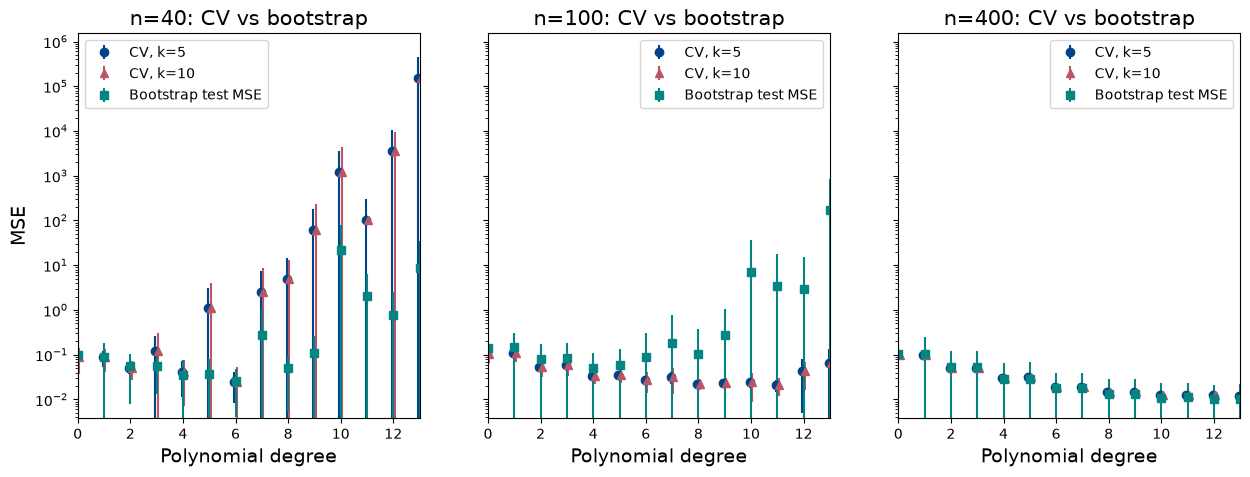

In [11]:
# Compare the MSE you get from cross-validation with the one you got from your bootstrap
# code in part c).

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, n in enumerate((40, 100, 400)):
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5, mse_k5_std  = cv_mse_ols(x_cv, y_cv, degree_max, k=5)
    mse_k10, mse_k10_std = cv_mse_ols(x_cv, y_cv, degree_max, k=10)
    error_boot, _, _, error_boot_std, _, _ = bootstrap_polynomial(n=n, degree_max=degree_max)

    # ax[i].plot(range(degree_max), mse_k5, "o-", label="CV, k=5", color="#004488")
    # ax[i].plot(range(degree_max), mse_k10, "o-", label="CV, k=10", color="#BB5566")
    ax[i].errorbar(np.arange(degree_max)-0.05, mse_k5, yerr = mse_k5_std, fmt='o', color="#004488", label="CV, k=5")
    ax[i].errorbar(np.arange(degree_max)+0.05, mse_k5, yerr = mse_k10_std, fmt='^', color="#BB5566", label="CV, k=10")
    ax[i].errorbar(range(degree_max), error_boot, yerr = error_boot_std, fmt='s', color=test_color, label= "Bootstrap test MSE")
    # ax[i].plot(range(degree_max), error_boot, "s--", label="Bootstrap test MSE", color=test_color)
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree", fontsize=14)
    ax[i].set_title(f"n={n}: CV vs bootstrap", fontsize=15)
    ax[i].legend()
    ax[i].set_xlim(0,13)

    print(f"n={n}: best degree — CV(k=5)={np.argmin(mse_k5)}, "
          f"CV(k=10)={np.argmin(mse_k10)}, bootstrap={np.argmin(error_boot)}")

ax[0].set_ylabel("MSE", fontsize=14)
plt.show()

## Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation



In [12]:
#Setting up the data
rng = np.random.default_rng(2026)     
degree = 5 
lmbda = 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

#Computing the gradients in two ways: analytically and by automatic differentiation

# Gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# The same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

# Verifying that the two graidents agree to maching precision for both OLS and Ridge:
print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# The largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())

OLS   max |AD - analytic| = 8.881784197001252e-16
Ridge max |AD - analytic| = 8.881784197001252e-16
eta_max for OLS  = 0.8937721839600538


lambda = 0.0: lambda_max = 5.6527, lambda_min = 0.0109, kappa = 520.3, gamma_max = 0.3538, gamma* = 0.3531
lambda = 0.01: lambda_max = 5.6727, lambda_min = 0.0309, kappa = 183.8, gamma_max = 0.3526, gamma* = 0.3507


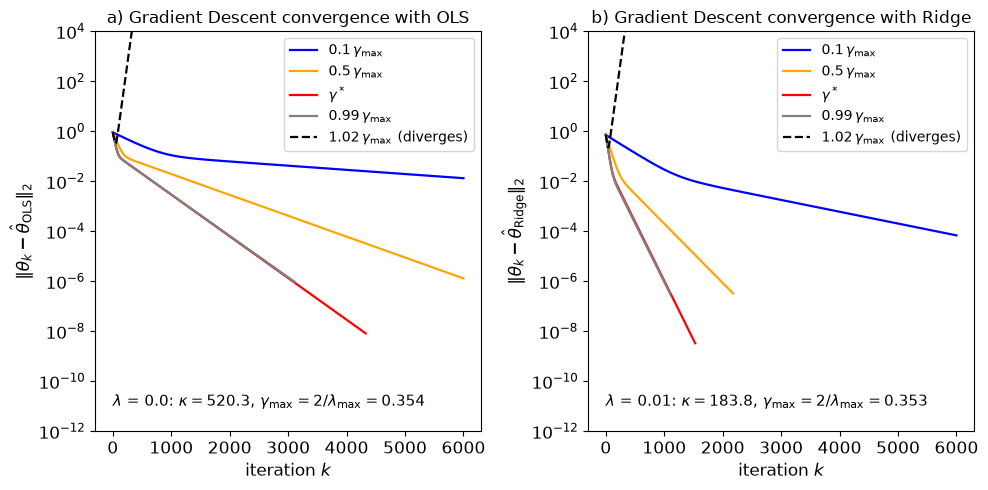

In [13]:
# Compare the gradient descent with the closed-form solution for OLS and Ridge regression

# Gradient descent function
grad_jax = jax.grad(cost)

# First version of gradient descent function, with option to use either analytical or automatic differentiation gradients
def gradient_descent(X,y,gamma,lmbda=0.0, num_iters=1000, tol=1e-8, method="analytical"):

    # Initialize weights for gradient descent
    n_features = X.shape[1]
    theta0 = np.zeros(n_features)
        
    history = [theta0.copy()]

    # Gradient descent loop
    for t in range(1,num_iters+1):
        # Compute gradients for OLS / Ridge    

        if method == "analytical":
            # the gradients by hand (analytically)
            g = gradient(theta0, X, y, lmbda)
        elif method == "AD":
            # gradients by automatic differentiation (with respect to argument 0 = theta)
            g = grad_jax(theta0, X, y, lmbda)
        
        # Update parameters theta
        theta0 = theta0 - gamma * g

        history.append(theta0.copy())
        
        # Stopping criterion:  gradient is small enough
        if np.linalg.norm(g) < tol:
            break
    
    return theta0, t, history


#Setting up the data for gradient descent
def exercise_data(n=100,sigma=0.1, seed=2026,degree=5):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    x, y, n, sigma = generate_data()
    X = design_matrix(x, degree,intercept=False)

    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered


#Function from tuesday week 37 exercise, tweaked to match the desired figures:
def fig_gd_convergence(filename="project1_gd_convergence.png"):

    fig, axes = plt.subplots(1,2, figsize=(10, 5))

    for ax, lam in zip(axes, lmbdas):
        #Getting the data and closed form solution for the given lambda:
        X,y = exercise_data(degree=degree)
        theta_cf = closed_form(X, y,lam=lam)
        #Getting the Hessian
        eigs = hessian_eigs(X,lam=lam)
        lmax, lmin = eigs.max(), eigs.min()
        #Finding optimal and maximum learning rates
        gamma_star, gamma_max = 2.0 / (lmax + lmin), 2.0 / lmax
        gammas = [0.1 * gamma_max, 0.5 * gamma_max, gamma_star, 0.99 * gamma_max, 1.02 * gamma_max] #Running with different gammas
        labels = [r"$0.1\,\gamma_{\max}$", r"$0.5\,\gamma_{\max}$", r"$\gamma^*$",
                    r"$0.99\,\gamma_{\max}$", r"$1.02\,\gamma_{\max}$ (diverges)"]
        colors = ["blue", "orange", "red", "grey", "black"]
        for gamma, lab, col in zip(gammas, labels, colors):
            
            # Running the gradient descent
            theta_gd, t, history = gradient_descent(X,y,gamma,lam, num_iters, tol,method="AD")
            # Getting the distance to the closed form
            dist = np.linalg.norm(np.asarray(history) - theta_cf, axis=1)
            # Plotting the results
            ax.semilogy(dist, color=col, label=lab, lw=1.6,
                        ls="--" if gamma > gamma_max else "-")
        # ax.set_title(rf"$\lambda$ = {lam}: $\kappa={lmax/lmin:.1f}$, "
        #                 rf"$\gamma_{{\max}}=2/\lambda_{{\max}}={gamma_max:.3f}$", fontsize=10)
        ax.text(1,1e-11,rf"$\lambda$ = {lam}: $\kappa={lmax/lmin:.1f}$, "
                        rf"$\gamma_{{\max}}=2/\lambda_{{\max}}={gamma_max:.3f}$", fontsize=11)
        ax.set_xlabel("iteration $k$",fontsize=12)
        ax.set_ylim(1e-12, 1e4)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=10, loc="upper right")
        if lam == 0.0: #Closed form for OLS
            ax.set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$",fontsize=12)
            ax.set_title(f"a) Gradient Descent convergence with OLS", fontsize=12)
        else: #Closed form for Ridge
            ax.set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Ridge}}\|_2$",fontsize=12)
            ax.set_title(f"b) Gradient Descent convergence with Ridge", fontsize=12)
    # plt.suptitle(f"Gradient descent convergence to closed form solution", fontsize=12)
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)



#Input data for gradient descent parameters:
num_iters = 6000 # The maximum number of iterations 
tol = 1e-8 # Tolerance for the stopping criterion
lmbdas = [0.0, 1e-2] # Lambda for regression (0 for OLS, >0 for Ridge)
degree = 5 # Degree of the polynomial 

X, y = exercise_data(degree=degree)
rng = np.random.default_rng(2026)

#Getting the Hessian eigenvalues and finding the condition number and maximum learning rate:
for lam in lmbdas:
    eigs = hessian_eigs(X,lam=lam)
    print(f"lambda = {lam}: lambda_max = {eigs.max():.4f}, lambda_min = {eigs.min():.4f}, "
            f"kappa = {eigs.max()/eigs.min():.1f}, gamma_max = {2/eigs.max():.4f}, "
            f"gamma* = {2/(eigs.max()+eigs.min()):.4f}")


# Plotting the convergence of gradient descent for different learning rates
with np.errstate(all="ignore"):
    fig_gd_convergence("project1_gd_convergence.png")

Image("project1_gd_convergence.png")


### Part f): Including momentum and more advanced ways to update the learning rate

In [14]:

# Creating a dictionary to store the best learning rates for each optimiser and regression type (note that this has been updated based on results further down in the notebook)
optimiser_dict = {
    "plain": {
        "OLS": 0.251,
        "Ridge": 0.251,
        "Lasso": 0.251,
        "color": "gray"
    },
    "momentum": {
        "OLS": 0.251,
        "Ridge": 0.100,
        "Lasso": 0.251,
        "color": "blue"
    },
    "adagrad": {
        "OLS": 0.063,
        "Ridge": 0.100,
        "Lasso": 0.063,
        "color": "orange"
    },
    "rmsprop": {
        "OLS": 0.0,
        "Ridge": 0.010,
        "Lasso": 0.0,
        "color": "green"
    },
    "adam": {
        "OLS": 0.025,
        "Ridge": 0.063,
        "Lasso": 0.025,
        "color": "red"
    },
    "lmbdas": {
        "OLS": 0.0,
        "Ridge": 1e-2,
        "Lasso": 1e-5
    },
}

<>:87: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:143: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:87: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:143: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\1525790441.py:87: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.set_title(f"{sub}) Initial learning rate $\gamma={g:.2g}$", fontsize=12)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\1525790441.py:143: SyntaxWarning: "

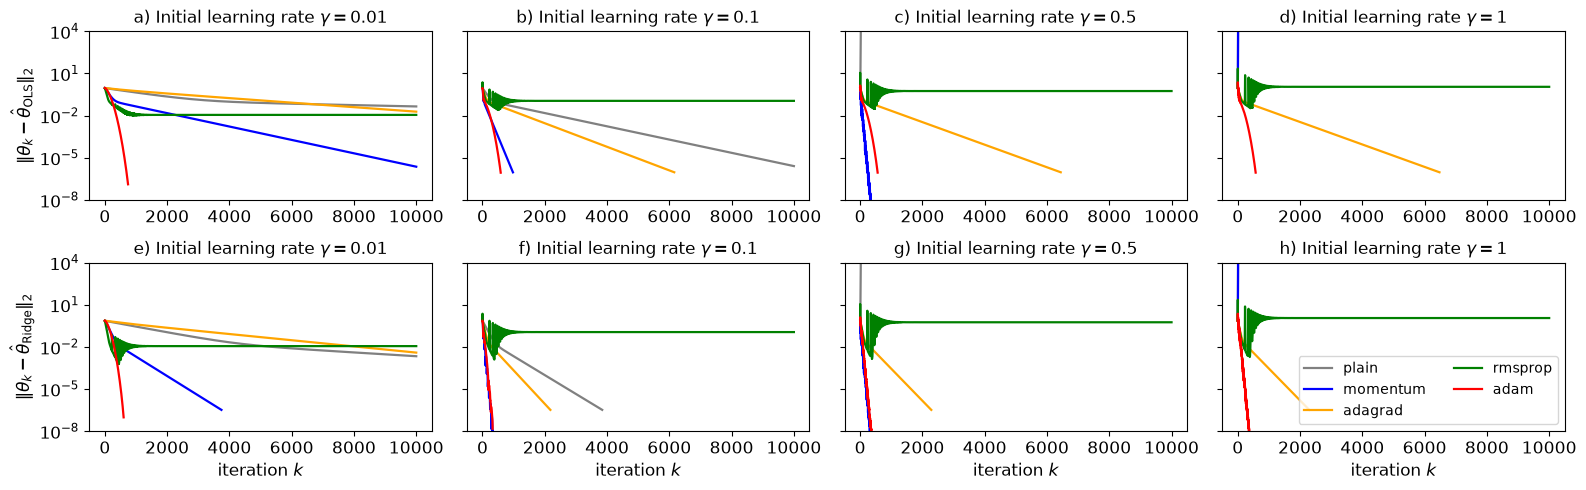

plain   : usable gamma from 0.0251 to 0.2512 ; best 840 iterations at gamma = 0.251
momentum: usable gamma from 0.0025 to 0.6310 ; best 110 iterations at gamma = 0.251
adagrad : usable gamma from 0.0158 to 1.0000 ; best 1130 iterations at gamma = 0.063
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 170 iterations at gamma = 0.025
plain   : usable gamma from 0.0063 to 0.2512 ; best 250 iterations at gamma = 0.251
momentum: usable gamma from 0.0010 to 0.6310 ; best 100 iterations at gamma = 0.100
adagrad : usable gamma from 0.0100 to 1.0000 ; best 340 iterations at gamma = 0.100
rmsprop : usable gamma from 0.0025 to 1.0000 ; best 200 iterations at gamma = 0.010
adam    : usable gamma from 0.0010 to 1.0000 ; best 110 iterations at gamma = 0.063


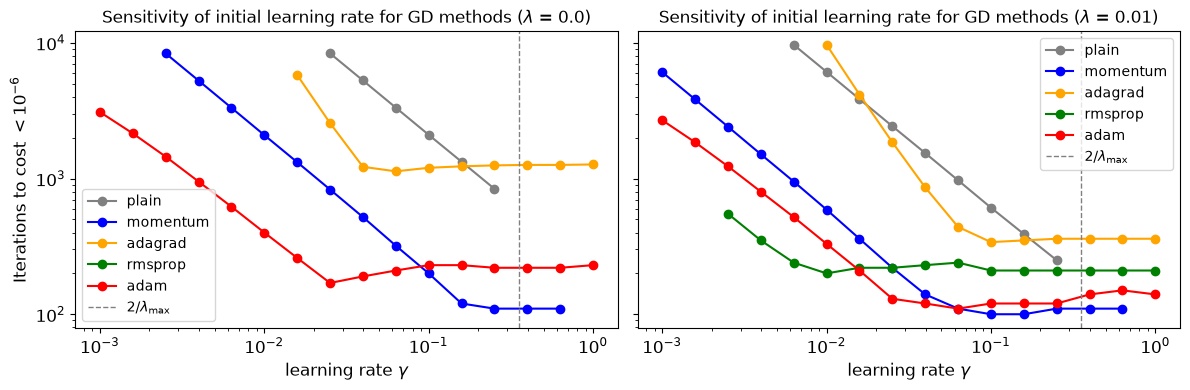

In [15]:

#Function from exercises, equations for various methods with gradient descent
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t (t = 1, 2, ...), Eqs. (4.10), (4.28),
    (4.42)-(4.45), (4.47)-(4.48) and (4.51)-(4.55).  state carries the running quantities."""
    if method == "plain":
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g               # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.42)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.45)
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.47)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.48)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.51)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.52)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.54)
        r_hat = r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state   # Eq. (4.55)
    raise ValueError(f"unknown method {method}")

   
# Updated gradient_descent function to include the different methods from the optimiser_step function
def gradient_descent(X,y,gamma,lmbda=0.0, num_iters=1000, tol=1e-8, method="plain"):

    # Initialize weights for gradient descent
    n_features = X.shape[1]
    theta0 = np.zeros(n_features)
    
    history = [theta0.copy()]
    theta_an, state = np.array(theta0, dtype=float), {}

    # Gradient descent loop
    for t in range(1, num_iters+1):
        # Compute gradients for OLS / Ridge    

        # the gradients by hand (analytically)
        g = gradient(theta_an, X, y, lmbda)

        # Update parameters theta, depending on method:
        theta_an, state = optimiser_step(method, theta_an, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8)

        history.append(theta_an.copy())
        
        # Stopping criterion:  gradient is small enough
        if np.linalg.norm(g) < tol:
            break

    return theta_an, t, history



# Input variables:
gammas = np.geomspace(1e-3, 1.0, 16)
num_iters = 10000
tol = 1e-8
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
subs = ["a","b","c","d","e","f","g","h"]

X, y = exercise_data(degree=degree)

#Plotting the results
fig, axes = plt.subplots(2,4,figsize=(16, 5),sharey=True)

# Calculations for both OLS and Ridge regression, for 4 selected learning rates
for ax, g, lmbda, sub in zip(axes.flatten(), (0.01,0.1,0.5,1,0.01,0.1,0.5,1),(0,0,0,0,1e-2,1e-2,1e-2,1e-2),subs): 

    # Getting the closed-form solution
    theta_cf = closed_form(X, y, lam=lmbda)
            
    # Loop over different methods
    for method in methods:
        # Running the gradient descent
        theta_gd, t, history = gradient_descent(X, y, g, lmbda, num_iters, tol, method=method)
        # Getting the distance to the closed form solution
        dist = np.linalg.norm(np.asarray(history) - theta_cf, axis=1)

        ax.semilogy(dist, color=optimiser_dict[method]["color"], label=method, lw=1.6)
    ax.set_title(f"{sub}) Initial learning rate $\gamma={g:.2g}$", fontsize=12)
    ax.set_ylim(1e-8, 1e4)
    ax.tick_params(axis='both', labelsize=12)


axes[0,0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$",fontsize=12)
axes[1,0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Ridge}}\|_2$",fontsize=12)
axes[1,0].set_xlabel("iteration $k$",fontsize=12)
axes[1,1].set_xlabel("iteration $k$",fontsize=12)
axes[1,2].set_xlabel("iteration $k$",fontsize=12)
axes[1,3].set_xlabel("iteration $k$",fontsize=12)
axes[1,3].legend(ncol=2,fontsize=10, loc="lower right")

fig.tight_layout()
fig.savefig("project1_taskf1.png", bbox_inches="tight")

plt.show()




# Finding the best initial learning rate for each method, scanning over a range of learning rates

np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error

fig, axes = plt.subplots(1,2,figsize=(12, 4.0),sharey=True)
# Doing the test for both OLS and Ridge regression
for lmbda, ax in zip(lmbdas, axes):
    #Finding the closed-form solution
    theta_cf = closed_form(X, y, lam=lmbda)
    cost_cf = cost(theta_cf, X, y, lam=lmbda)
    eigs = hessian_eigs(X, lam=lmbda)

    scan = {}
    # Looping over the different methods
    for method in methods:
        its = []
        for g in gammas:
            theta_gd, t, history = gradient_descent(X, y, g, lmbda, num_iters, tol, method=method)
            
            # Getting the distance to the closed form solution
            e = np.array([cost(h, X, y,lam=lmbda) - cost_cf for h in history[::10]])
            
            its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
        scan[method] = its
        #Finding the usable and best gammas for each method:
        ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
        best = min(ok, key=lambda t: t[1]) if ok else None
        print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
            f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")

        its = np.array([np.nan if k is None else k for k in scan[method]])
        ax.loglog(gammas, its, "o-", color=optimiser_dict[method]["color"], label=method)
    ax.axvline(2 / eigs.max(), color="gray", ls="--", lw=1, label=r"$2/\lambda_{\max}$")
    ax.set_xlabel(r"learning rate $\gamma$",fontsize=12)
    
    ax.set_title(f"Sensitivity of initial learning rate for GD methods ($\lambda$ = {lmbda})", fontsize=12)
    ax.legend(fontsize=10)
    ax.tick_params(axis='both', labelsize=12)


axes[0].set_ylabel("Iterations to cost $<10^{-6}$", fontsize=12)
fig.tight_layout()
plt.show()


# Learning rate gamma
gamma = 0.1


### Part g): Writing our own code for Lasso regression

In [16]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
print("Subgradient at theta = 0:")
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))


# 3. The Lasso convention. Our coordinate-descent solver with a soft threshold
#    minimises ||y - X theta||^2 / n + lambda ||theta||_1.
def soft_threshold(z, lmbda):
    return np.sign(z) * np.maximum(np.abs(z) - lmbda/2.0, 0.0) # Eq. (3.63)
   
# Updated gradient_descent function to include a soft threshold for lasso
def gradient_descent(X,y,gamma,lmbda=0.0, num_iters=1000, tol=1e-8, method="plain",reg_method="lasso"):

    # Initialize weights for gradient descent
    n_features = X.shape[1]
    theta0 = np.zeros(n_features)
    
    history = [theta0.copy()]
    theta_an, state = np.array(theta0, dtype=float), {}

    # Gradient descent loop
    for t in range(1, num_iters+1):

        # The gradients by hand (analytically)
        g = gradient(theta_an, X, y, lmbda)

        # Update parameters theta, depending on method:
        theta_an, state = optimiser_step(method, theta_an, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8)

        # Soft threshold (if Lasso)
        if reg_method == "Lasso":
            theta_an = soft_threshold(theta_an, lmbda)

        history.append(theta_an.copy())
        
        # Stopping criterion:  gradient is small enough
        if np.linalg.norm(g) < tol:
            break

    return theta_an, t, history


#Studying the sensitivity of the methods to initial learning rate for different penalty parameters for Lasso regression
np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error

for lmbda in [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    print("Penalty parameter: ", lmbda)
    
    theta_cf = Lasso(alpha=lmbda / 2.0, fit_intercept=False, max_iter=10000, 
                tol=1e-12).fit(X, y).coef_     
    cost_cf = cost_lasso(theta_cf, X, y, lam=lmbda)

    scan = {}
    for method in methods:
        its = []
        for g in gammas:
            theta_gd, t, history = gradient_descent(X, y, g, lmbda=lmbda, num_iters=num_iters, tol=tol, method=method,reg_method="Lasso")

            e = np.array([cost_lasso(h, X, y,lam=lmbda) - cost_cf for h in history[::10]])

            its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
        scan[method] = its
        #Finding the usable and best gammas for each method:
        ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
        best = min(ok, key=lambda t: t[1]) if ok else None
        print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
            f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")


Subgradient at theta = 0:
jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0
Penalty parameter:  1e-05
plain   : usable gamma from 0.0631 to 0.2512 ; best 880 iterations at gamma = 0.251
momentum: usable gamma from 0.0063 to 0.6310 ; best 90 iterations at gamma = 0.251
adagrad : usable gamma from 0.0251 to 1.0000 ; best 1230 iterations at gamma = 0.063
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 170 iterations at gamma = 0.025
Penalty parameter:  0.0001
plain   : never reaches 1e-6 
momentum: usable gamma from 0.0398 to 0.6310 ; best 110 iterations at gamma = 0.158
adagrad : never reaches 1e-6 
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 160 iterations at gamma = 0.040
Penalty parameter:  0.001
plain   : never reaches 1e-6 
momentum: never reaches 1e-6 
adagrad : never reaches 1e-6 
rmsprop : never reaches 1e-6 
adam    : never reaches 1e-6 
Penalty parameter:  0.01
plain 

plain   : usable gamma from 0.0251 to 0.2512 ; best 840 iterations at gamma = 0.251
momentum: usable gamma from 0.0025 to 0.6310 ; best 110 iterations at gamma = 0.251
adagrad : usable gamma from 0.0158 to 1.0000 ; best 1130 iterations at gamma = 0.063
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 170 iterations at gamma = 0.025
plain   : usable gamma from 0.0063 to 0.2512 ; best 250 iterations at gamma = 0.251
momentum: usable gamma from 0.0010 to 0.6310 ; best 100 iterations at gamma = 0.100
adagrad : usable gamma from 0.0100 to 1.0000 ; best 340 iterations at gamma = 0.100
rmsprop : usable gamma from 0.0025 to 1.0000 ; best 200 iterations at gamma = 0.010
adam    : usable gamma from 0.0010 to 1.0000 ; best 110 iterations at gamma = 0.063
plain   : usable gamma from 0.0631 to 0.2512 ; best 880 iterations at gamma = 0.251
momentum: usable gamma from 0.0063 to 0.6310 ; best 90 iterations at gamma = 0.251
adagrad : usable gamma from 0.0251 to 1.0000 ;

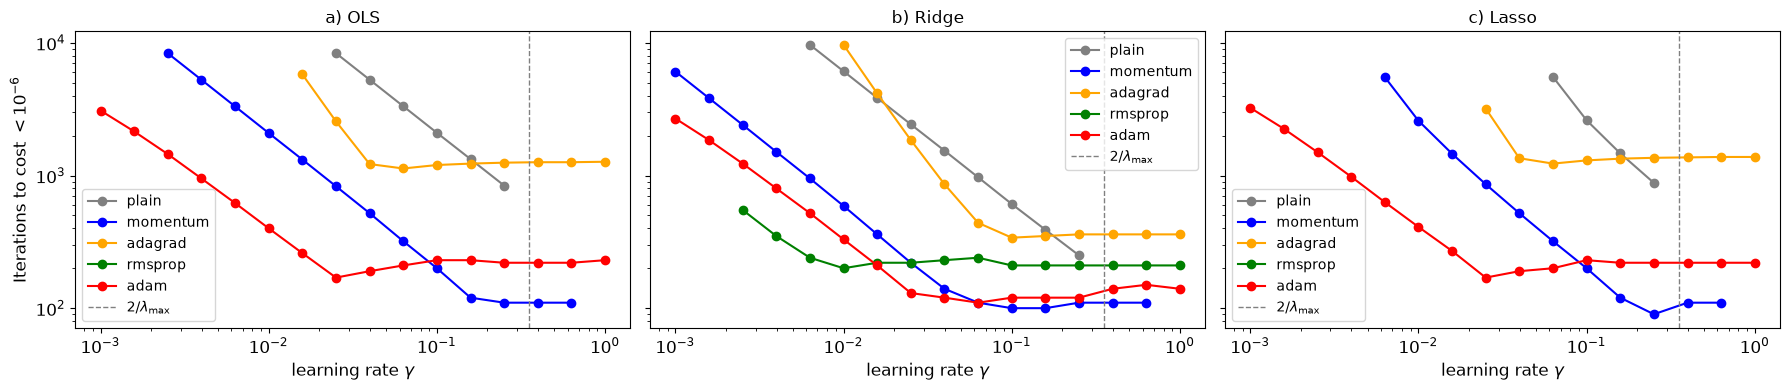

plain   : usable gamma from 0.0251 to 0.2512 ; best 840 iterations at gamma = 0.251
momentum: usable gamma from 0.0025 to 0.6310 ; best 110 iterations at gamma = 0.251
adagrad : usable gamma from 0.0158 to 1.0000 ; best 1130 iterations at gamma = 0.063
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 170 iterations at gamma = 0.025
plain   : usable gamma from 0.0063 to 0.2512 ; best 250 iterations at gamma = 0.251
momentum: usable gamma from 0.0010 to 0.6310 ; best 100 iterations at gamma = 0.100
adagrad : usable gamma from 0.0100 to 1.0000 ; best 340 iterations at gamma = 0.100
rmsprop : usable gamma from 0.0025 to 1.0000 ; best 200 iterations at gamma = 0.010
adam    : usable gamma from 0.0010 to 1.0000 ; best 110 iterations at gamma = 0.063
plain   : usable gamma from 0.0631 to 0.2512 ; best 880 iterations at gamma = 0.251
momentum: usable gamma from 0.0063 to 0.6310 ; best 90 iterations at gamma = 0.251
adagrad : usable gamma from 0.0251 to 1.0000 ;

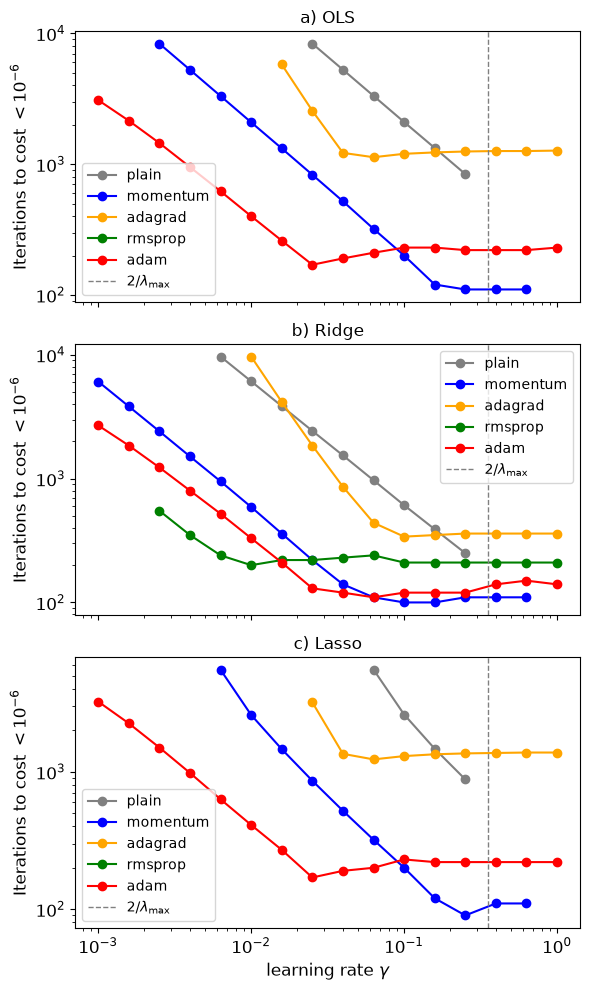

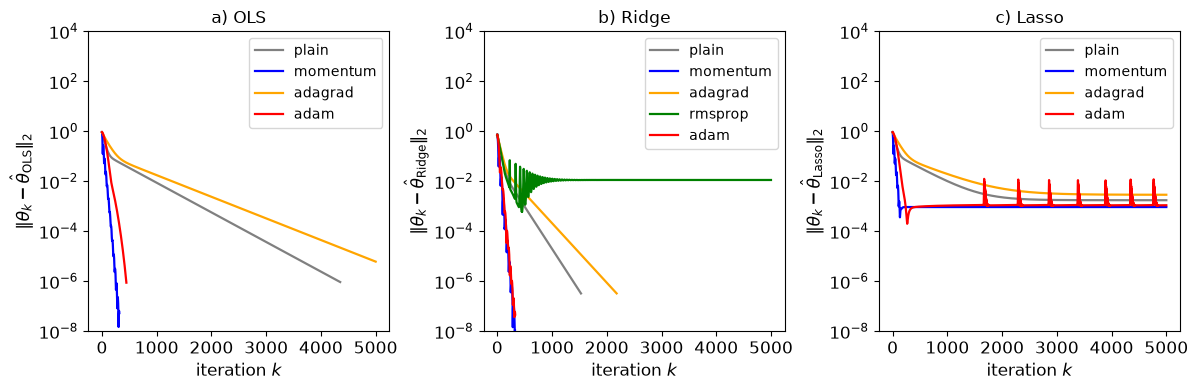

own gradient descent: [-0.022881 -0.7376    0.123125  0.528758 -0.074914]
sklearn Lasso(alpha=lambda/2): [-0.022608 -0.737641  0.122274  0.528822 -0.074297]
agree at tolerance of 1e-3: True


In [17]:
# Finding the best initial learning rate for each method, scanning over a range of learning rates
np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error

fig, axes = plt.subplots(1,3,figsize=(18, 4.0),sharey=True)
# Doing the test for OLS, Ridge, and Lasso regression
for ax, reg_method, sub in zip(axes, ("OLS","Ridge","Lasso"), ("a","b","c")):

    lmb = optimiser_dict["lmbdas"][reg_method]

    #Finding the closed-form solution
    if reg_method == "Lasso": #Lasso does not have a closed-form solution, so use sci-kit learn instead
        theta_cf = Lasso(alpha= lmb / 2.0, fit_intercept=False, max_iter=num_iters,
                  tol=tol).fit(X, y).coef_ 
        cost_cf = cost_lasso(theta_cf, X, y, lam=lmb) #for Lasso, the cost is computed with the Lasso solution from sklearn
    else:
        theta_cf = closed_form(X, y, lam=lmb)
        cost_cf = cost(theta_cf, X, y, lam=lmb)
    
    eigs = hessian_eigs(X, lam=lmb)

    scan = {}
    # Looping over the different methods
    for method in methods:
        its = []
        for g in gammas:
            theta_gd, t, history = gradient_descent(X, y, g, lmb, num_iters, tol, method=method,reg_method=reg_method)

            # Getting the distance to the closed form solution
            if reg_method == "Lasso":
                e = np.array([cost_lasso(h, X, y,lam=lmb) - cost_cf for h in history[::10]])
            else:
                e = np.array([cost(h, X, y,lam=lmb) - cost_cf for h in history[::10]])

            its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
        scan[method] = its
        # Finding the usable and best gammas for each method:
        ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
        best = min(ok, key=lambda t: t[1]) if ok else None
        print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
            f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")

        its = np.array([np.nan if k is None else k for k in scan[method]])
        ax.loglog(gammas, its, "o-", color=optimiser_dict[method]["color"], label=method)

    ax.axvline(2 / eigs.max(), color="gray", ls="--", lw=1, label=r"$2/\lambda_{\max}$")
    ax.set_xlabel(r"learning rate $\gamma$",fontsize=12);     
    ax.set_title(f"{sub}) {reg_method}", fontsize=12)
    ax.legend(fontsize=10)
    ax.tick_params(axis='both', labelsize=12)

axes[0].set_ylabel("Iterations to cost $<10^{-6}$", fontsize=12)
fig.tight_layout()
fig.savefig("project1_taskg1.png", bbox_inches="tight")
plt.show()


#Same figure, but with one column instead of three
fig, axes = plt.subplots(3,1,figsize=(6, 10),sharex=True)
# Doing the test for OLS, Ridge, and Lasso regression
for ax, reg_method, sub in zip(axes, ("OLS","Ridge","Lasso"), ("a","b","c")):

    lmb = optimiser_dict["lmbdas"][reg_method]

    #Finding the closed-form solution
    if reg_method == "Lasso":
        theta_cf = Lasso(alpha= lmb / 2.0, fit_intercept=False, max_iter=num_iters,
                  tol=tol).fit(X, y).coef_ 
        cost_cf = cost_lasso(theta_cf, X, y, lam=lmb) #for Lasso, the cost is computed with the Lasso solution from sklearn, since there is no closed form solution for Lasso
    else:
        theta_cf = closed_form(X, y, lam=lmb)
        cost_cf = cost(theta_cf, X, y, lam=lmb)
    
    eigs = hessian_eigs(X, lam=lmb)

    scan = {}
    # Looping over the different methods
    for method in methods:
        its = []
        for g in gammas:
            theta_gd, t, history = gradient_descent(X, y, g, lmb, num_iters, tol, method=method,reg_method=reg_method)
            
            # Getting the distance to the closed form solution
            if reg_method == "Lasso":
                e = np.array([cost_lasso(h, X, y,lam=lmb) - cost_cf for h in history[::10]])
            else:
                e = np.array([cost(h, X, y,lam=lmb) - cost_cf for h in history[::10]])

            its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
        scan[method] = its
        #Finding the usable and best gammas for each method:
        ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
        best = min(ok, key=lambda t: t[1]) if ok else None
        print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
            f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")

        its = np.array([np.nan if k is None else k for k in scan[method]])
        ax.loglog(gammas, its, "o-", color=optimiser_dict[method]["color"], label=method)

    ax.axvline(2 / eigs.max(), color="gray", ls="--", lw=1, label=r"$2/\lambda_{\max}$")
    ax.set_ylabel("Iterations to cost $<10^{-6}$", fontsize=12)    
    ax.set_title(f"{sub}) {reg_method}", fontsize=12)
    ax.legend(fontsize=10)
    ax.tick_params(axis='both', labelsize=12)
axes[2].set_xlabel(r"learning rate $\gamma$",fontsize=12) 
fig.tight_layout()
fig.savefig("project1_taskg1_v2.png", bbox_inches="tight")
plt.show()



# Plotting the convergence of gradient descent for different methods and regression types (OLS, Ridge, Lasso) using the best learning rates found in the previous step
fig, axes = plt.subplots(1,3,figsize=(12, 4))
for ax, reg_method, sub in zip(axes, ("OLS","Ridge","Lasso"), ("a","b","c")):

    lmb = optimiser_dict["lmbdas"][reg_method]

    if reg_method == "OLS":
        theta_ref = closed_form(X, y, lam=lmb)
    elif reg_method == "Ridge":
        theta_ref = closed_form(X, y, lam=lmb)
    else:
        theta_ref = Lasso(alpha= lmb / 2.0, fit_intercept=False, max_iter=5000,
                  tol=tol).fit(X, y).coef_ 

    # Looping over the different methods
    for method in methods:
        gamma = optimiser_dict[method][reg_method]
        if gamma == 0: # Skip methods with zero learning rate (they do not converge and are just set at 0 in the dictionary)
            continue
        theta_gd, t, history = gradient_descent(X, y, gamma, lmb, 5000, tol, method=method, reg_method=reg_method)

        dist = np.linalg.norm(np.asarray(history) - theta_ref, axis=1)

        ax.semilogy(dist, color=optimiser_dict[method]["color"], label=method, lw=1.6)
    ax.set_title(f"{sub}) {reg_method}", fontsize=12)
    ax.set_xlabel("iteration $k$",fontsize=12)
    ax.set_ylim(1e-8, 1e4)
    ax.legend(fontsize=10, loc="upper right")
    ax.tick_params(axis='both', labelsize=12)

axes[0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$", fontsize=12)
axes[1].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Ridge}}\|_2$", fontsize=12)
axes[2].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Lasso}}\|_2$", fontsize=12)
fig.tight_layout()
fig.savefig("project1_taskg2.png", bbox_inches="tight")
plt.show()



#Comparing the Lasso gradient descent with the sklearn Lasso solution
print("own gradient descent:", np.round(theta_gd, 6))
print("sklearn Lasso(alpha=lambda/2):", np.round(theta_ref, 6))
print("agree at tolerance of 1e-3:", np.allclose(theta_gd, theta_ref, atol=1e-3))

## Part h): Stochastic gradient descent

full gradient: [-3.63576963  3.08698393 -3.71753913  3.23125842 -3.63438032]
Dependence of batch size M and epochs n_epochs and learning rate gamma on the distance to the closed-form solution:
M =  1: mean [-3.636  3.087 -3.718  3.231 -3.634], spread 10.640


<>:71: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:71: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_25100\3595024398.py:71: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.semilogy(epochs*n,d,label=f"{method}, $\gamma$={optimiser_dict[method][reg_method]:.3f}", color=optimiser_dict[method]["color"], lw=1.6)


M = 1, gamma = 0.1: distance after 1 / 10 / 100 epochs 6.8e+01 / 8.8e+10 / 3.6e+102, min over the last 50 epochs 6.1e+51
M =  1: mean [-3.636  3.087 -3.718  3.231 -3.634], spread 10.640
M = 1, gamma = 0.02: distance after 1 / 10 / 100 epochs 7.8e-01 / 2.2e-01 / 2.0e-02, min over the last 50 epochs 2.0e-02
M =  5: mean [-3.636  3.087 -3.718  3.231 -3.634], spread 4.629
M = 5, gamma = 0.1: distance after 1 / 10 / 100 epochs 7.9e-01 / 2.4e-01 / 2.9e-02, min over the last 50 epochs 2.1e-02
M =  5: mean [-3.636  3.087 -3.718  3.231 -3.634], spread 4.623
M = 5, gamma = 0.02: distance after 1 / 10 / 100 epochs 8.8e-01 / 6.7e-01 / 9.9e-02, min over the last 50 epochs 9.9e-02
M = 25: mean [-3.636  3.087 -3.718  3.231 -3.634], spread 1.742
M = 25, gamma = 0.1: distance after 1 / 10 / 100 epochs 8.8e-01 / 6.7e-01 / 9.8e-02, min over the last 50 epochs 9.8e-02
M = 25: mean [-3.636  3.087 -3.718  3.231 -3.634], spread 1.907
M = 25, gamma = 0.02: distance after 1 / 10 / 100 epochs 9.1e-01 / 8.5e-01 

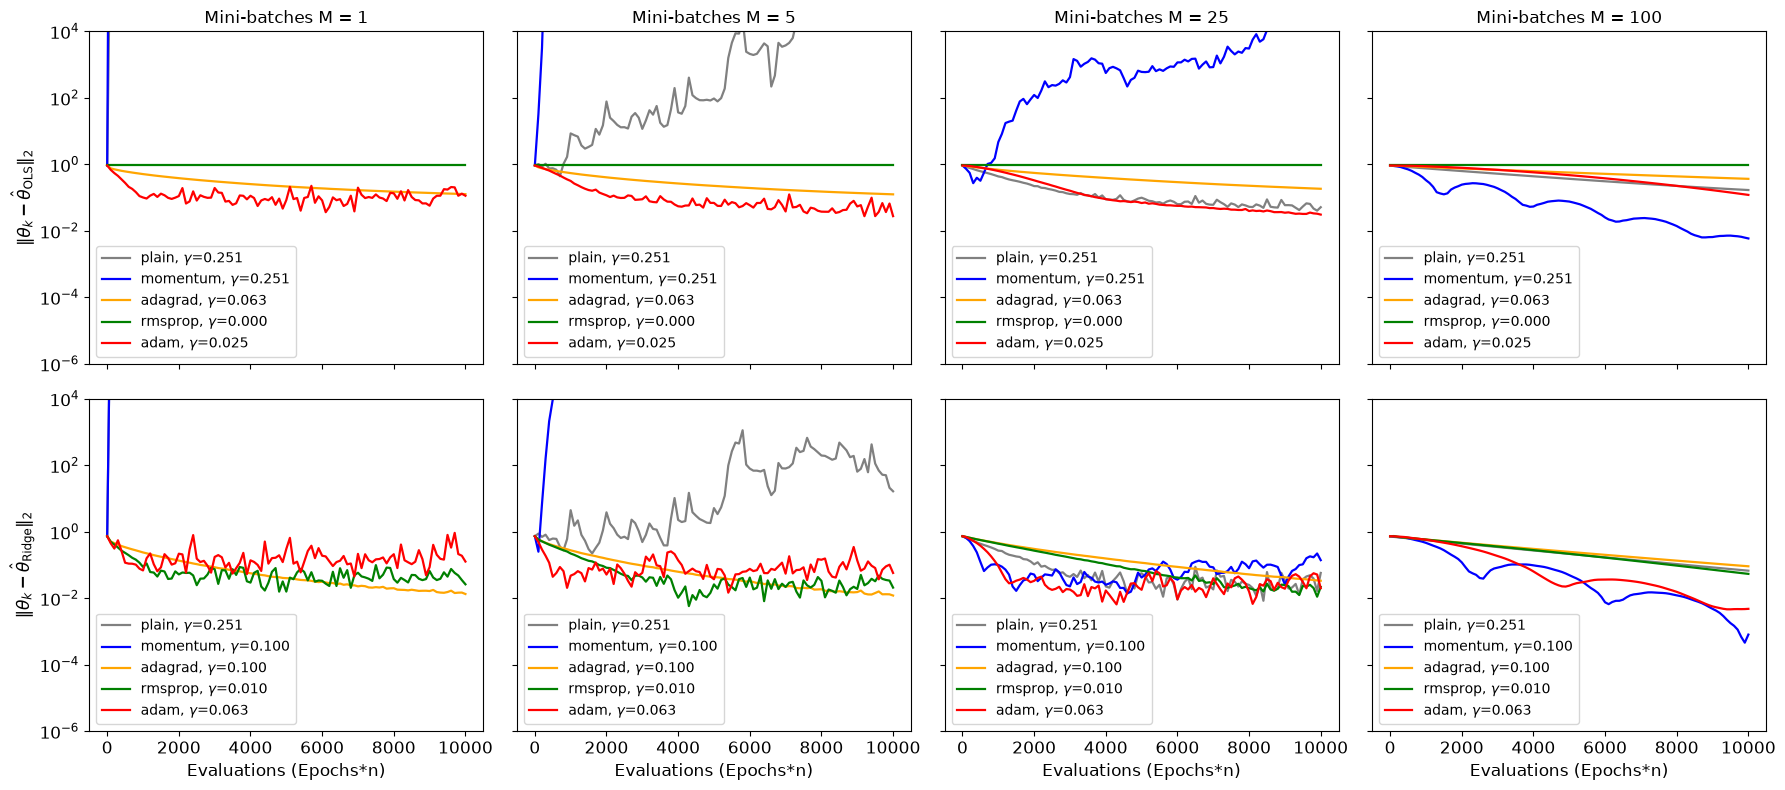

plain    gamma = 0.251: distance after 10 / 100 epochs 4.4e+00 / 1.6e+01
momentum gamma = 0.100: distance after 10 / 100 epochs 8.9e+07 / 9.7e+82
adagrad  gamma = 0.100: distance after 10 / 100 epochs 2.7e-01 / 1.2e-02
rmsprop  gamma = 0.010: distance after 10 / 100 epochs 2.2e-01 / 2.1e-02
adam     gamma = 0.063: distance after 10 / 100 epochs 4.7e-02 / 5.7e-02


In [18]:
rng = np.random.default_rng(2026)

#Functions from exercises
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches (Section 4.7)."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The learning-rate schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None, **kw):
    """Minibatch stochastic gradient descent, Eq. (4.34), with any optimiser of optimiser_step.
    schedule=(t0, t1) replaces the constant gamma by Eq. (4.40).  Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype=float)
    state, t, history = {}, 0, [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)            # Eq. (4.33): the minibatch gradient
            g_t = gamma if schedule is None else step_length(t, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, g_t, **kw)
        history.append(theta.copy())
    return np.array(history)


# Input parameters
X, y = exercise_data(degree=degree)
n = len(y)
theta_cf = closed_form(X, y)
theta = rng.normal(size=X.shape[1])
g_full = gradient(theta, X, y)
print("full gradient:", g_full)
epochs = np.arange(0, 101)



print("Dependence of batch size M and epochs n_epochs and learning rate gamma on the distance to the closed-form solution:")
for M in (1, 5, 25):
    for gamma in (0.1, 0.02):
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        print(f"M = {M:2d}: mean {np.round(gs.mean(axis=0), 3)}, spread {np.std(gs, axis=0).mean():.3f}")

        hist = sgd(X, y, n_epochs=100, batch_size=M, gamma=gamma)
        d = np.linalg.norm(hist - theta_cf, axis=1)
        print(f"M = {M}, gamma = {gamma}: distance after 1 / 10 / 100 epochs {d[1]:.1e} / {d[10]:.1e} / {d[100]:.1e}, "
            f"min over the last 50 epochs {d[50:].min():.1e}")


# Plotting the convergence of gradient descent for different batches
fig, axes = plt.subplots(2,4,figsize=(18, 8),sharey=True,sharex=True)
for ax, M,lmbda, sub in zip(axes.flatten(), (1, 5, 25, n,1,5,25,n),(0,0,0,0,1e-2,1e-2,1e-2,1e-2),subs): 

    if lmbda == 0.0:
        reg_method = "OLS"
    else:
        reg_method = "Ridge"

    theta_cf = closed_form(X, y,lam=lmbda)

    for method in methods: #also need to add RmSprop
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        # Calculating the SGD for the given method, batch size, and learning rate
        hist = sgd(X, y, n_epochs=100, batch_size=M, gamma=optimiser_dict[method][reg_method],method=method,lam=lmbda)
        # Finding the distance to the closed-form solution
        d = np.linalg.norm(hist - theta_cf, axis=1)
        ax.semilogy(epochs*n,d,label=f"{method}, $\gamma$={optimiser_dict[method][reg_method]:.3f}", color=optimiser_dict[method]["color"], lw=1.6) 
    
    ax.set_ylim(1e-6, 1e4)
    ax.legend(fontsize=10, loc="lower left")
    ax.tick_params(axis='both', labelsize=12)

axes[1,0].set_xlabel("Evaluations (Epochs*n)",fontsize=12)
axes[1,1].set_xlabel("Evaluations (Epochs*n)",fontsize=12)
axes[1,2].set_xlabel("Evaluations (Epochs*n)",fontsize=12)
axes[1,3].set_xlabel("Evaluations (Epochs*n)",fontsize=12)
axes[0,0].set_title("Mini-batches M = 1",fontsize=12)
axes[0,1].set_title("Mini-batches M = 5",fontsize=12)
axes[0,2].set_title("Mini-batches M = 25",fontsize=12)
axes[0,3].set_title(f"Mini-batches M = {n}",fontsize=12)
axes[0,0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$",fontsize=12)
axes[1,0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Ridge}}\|_2$",fontsize=12)
plt.tight_layout()
fig.savefig("project1_taskh1.png", bbox_inches="tight")

plt.show()


# Studying the convergence for different methods with Ridge at different epochs
for method in methods:
    hist = sgd(X, y, n_epochs=100, batch_size=5, gamma=optimiser_dict[method][reg_method], method=method,lam=lmbda)
    d = np.linalg.norm(hist - theta_cf, axis=1)
    print(f"{method:8s} gamma = {optimiser_dict[method][reg_method]:.3f}: distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")


0.0014443854499021358 (array([6]), array([23]))
schedule: t0:  30   t1:  115
0.0027324933784293147 (array([10]), array([24]))
schedule: t0:  50   t1:  120
0.001384002686157074 (array([1]), array([11]))
schedule: t0:  5   t1:  55
0.000957335289151821 (array([8]), array([8]))
schedule: t0:  40   t1:  40


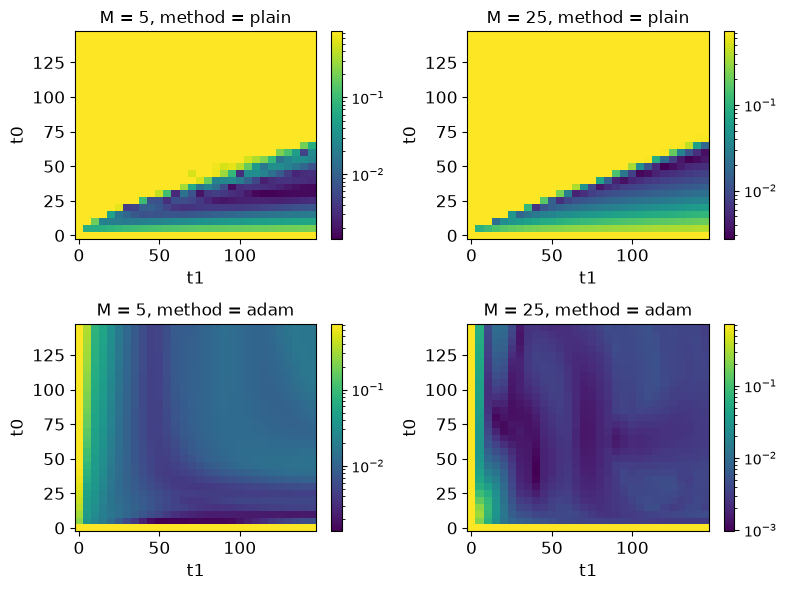

In [19]:
# Looping over different t0 and t1 to find the best schedule for different batch sizes M and selected methods (plain, adam):


M_scheds = {
    "plain": {
        5: (0, 0),
        25: (0, 0),
    }, 
    "adam": {
        5: (0, 0),
        25: (0, 0),
    }
}

t0s = np.arange(0, 150, 5)
t1s = np.arange(0, 150, 5)

theta_cf = closed_form(X, y,lam=optimiser_dict["lmbdas"]["Ridge"])

fig, axes = plt.subplots(2,2, figsize=(8, 6))
for M, ax, method in zip((5,25,5,25), axes.flatten(),("plain","plain","adam","adam")):
    heatmap = np.zeros((len(t0s), len(t1s)))
    
    gamma = optimiser_dict[method]["Ridge"]
    # Looping over different t0 and t1 to find the lowest distance to closed-form solution
    ii = 0
    for t0 in t0s:
        jj = 0  
        for t1 in t1s:
            sched = (t0, t1)
            
            hist = sgd(X, y, n_epochs=100, batch_size=M, schedule=sched,gamma=gamma,method=method,lam=optimiser_dict["lmbdas"]["Ridge"])
            d = np.linalg.norm(hist - theta_cf, axis=1)

            heatmap[ii, jj] = d.min()
            jj += 1
        ii += 1

    cm = ax.pcolormesh(t1s,t0s,heatmap, cmap="viridis",norm=matplotlib.colors.LogNorm())
    ax.set_xlabel(r"t1",fontsize=12)
    ax.set_ylabel(f"t0",fontsize=12)
    ax.set_title(f"M = {M}, method = {method}", fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

    plt.colorbar(cm,)
    
    print(heatmap.min(), np.where(heatmap == heatmap.min()))  # minimum distance and its location in the heatmap
    print("schedule: t0: ", t0s[np.where(heatmap == heatmap.min())[0][0]], "  t1: ", t1s[np.where(heatmap == heatmap.min())[1][0]])
    #Adding the best schedule to the dictionary for each method and batch size
    M_scheds[method][M] = (int(t0s[np.where(heatmap == heatmap.min())[0][0]]), int(t1s[np.where(heatmap == heatmap.min())[1][0]]))

fig.tight_layout()
fig.savefig("project1_taskh2_heatmap.png", bbox_inches="tight")

plt.show()


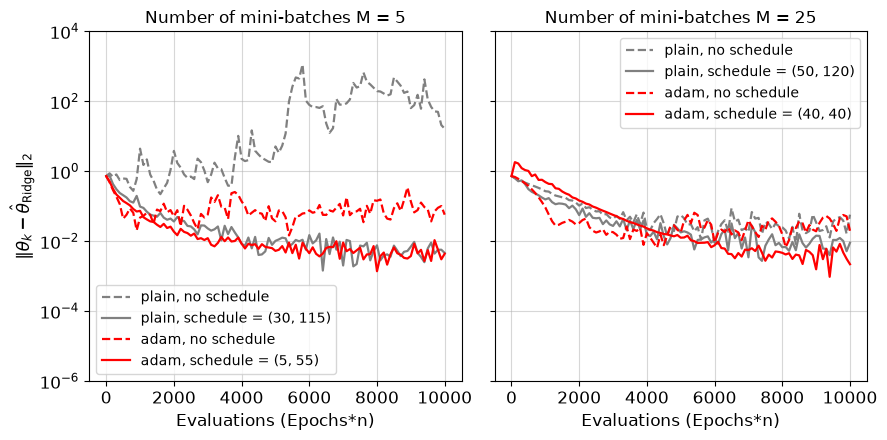

In [20]:
#Plotting the convergence with and without schedule
fig, axes = plt.subplots(1,2,figsize=(9, 4.5),sharey=True)
for ax, M in zip(axes.flatten(), (5, 25)): 

    theta_cf = closed_form(X, y,lam=optimiser_dict["lmbdas"]["Ridge"])
    
    for method in ["plain", "adam"]:
        #Getting the schedule for the given method and batch size
        sched = (M_scheds[method][M][0], M_scheds[method][M][1])

        #Make batches and computing the SGD
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        # Adding the SGD without a schedule for comparison
        hist_nosched = sgd(X, y, n_epochs=100, batch_size=M,schedule=None,gamma=optimiser_dict[method]["Ridge"],method=method,lam=optimiser_dict["lmbdas"]["Ridge"])
                
        #Finding the distance to the closed-form solution
        d_nosched = np.linalg.norm(hist_nosched - theta_cf, axis=1)
        
        ax.semilogy(epochs*n,d_nosched,"--", label=f"{method}, no schedule",color=optimiser_dict[method]["color"], lw=1.6)

        #Adding the SGD with the best schedule for comparison
        hist = sgd(X, y, n_epochs=100, batch_size=M,schedule=sched,gamma=optimiser_dict[method]["Ridge"],method=method,lam=optimiser_dict["lmbdas"]["Ridge"])
        
        #Finding the distance to the closed-form solution
        d = np.linalg.norm(hist - theta_cf, axis=1)
        
        ax.semilogy(epochs*n,d, label=f"{method}, schedule = {sched}",color=optimiser_dict[method]["color"], lw=1.6)

        
    ax.set_ylim(1e-6, 1e4)
    ax.grid(alpha=0.5)
    ax.legend(ncol=1)
    ax.tick_params(axis='both', labelsize=12)

axes[0].set_xlabel("Evaluations (Epochs*n)",fontsize=12)
axes[1].set_xlabel("Evaluations (Epochs*n)",fontsize=12)
axes[0].set_title("Number of mini-batches M = 5",fontsize=12)
axes[1].set_title("Number of mini-batches M = 25",fontsize=12)
axes[0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Ridge}}\|_2$",fontsize=12)

plt.tight_layout()
fig.savefig("project1_taskh2_convergence.png", bbox_inches="tight")
plt.show()

## Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

GD: 0.167332 vs  sklearn: 0.169355
Minimum MSE:  0.14795011478190592  Best degree:  6
Minimum MSE:  0.14770630546710922 Best degree:  6   lambda:  0.0002872984833353666
Minimum MSE:  0.14769416163935317 Best degree:  6   lambda:  6.812920690579608e-05


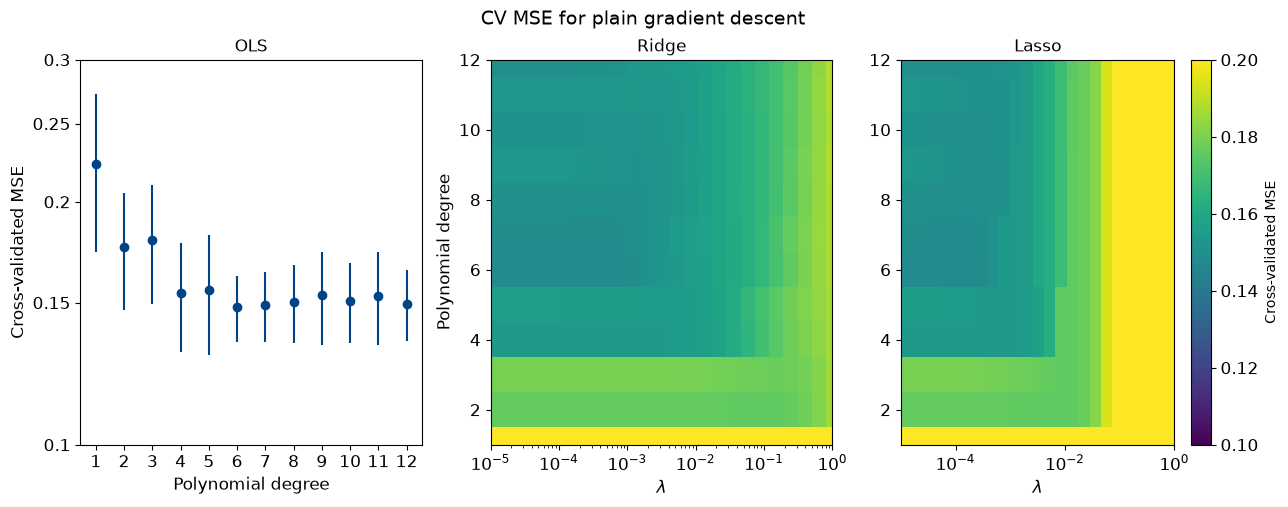

In [21]:
#CV MSE calculation for OLS regression

# From d) own implementation of CV MSE, adjusted to include gradient descent and the different regression methods (OLS, Ridge, Lasso)
def my_kfold_mse(x, y, degree, lmb, k, method="plain", reg_method="OLS", seed=2026):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    poly = PolynomialFeatures(degree=degree)
    fold_mse = np.zeros(k)

    for j, (train_idx, test_idx) in enumerate(kf.split(x)):
        x_train, y_train = x[train_idx], y[train_idx]
        x_test,  y_test  = x[test_idx],  y[test_idx]

        X_train = poly.fit_transform(x_train)
        X_test  = poly.transform(x_test)

        scaler = StandardScaler().fit(X_train)

        theta_gd, _, _ = gradient_descent(scaler.transform(X_train), y_train, 0.1, lmb, num_iters, tol, method=method, reg_method=reg_method) #optimiser_dict[method][reg_method]

        y_pred = scaler.transform(X_test) @ theta_gd

        fold_mse[j] = np.mean((y_test - y_pred) ** 2)

    return fold_mse.mean(), fold_mse.std()

x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
x_cv = x_cv.reshape(-1, 1)

# Sanity check against cross_val_score, at one (degree, lambda) point
degree_check, lmb_check, k_check = 6, 0.1, 5
mine, mine_std = my_kfold_mse(x_cv, y_cv, degree_check, lmb_check, k_check)

kf = KFold(n_splits=k_check, shuffle=True, random_state=2026)
pipe = make_pipeline(PolynomialFeatures(degree=degree_check), StandardScaler(), Ridge(alpha=n*lmb_check,fit_intercept=False))
sklearn_mse = -cross_val_score(pipe, x_cv, y_cv, cv=kf, scoring="neg_mean_squared_error").mean()

print(f"GD: {mine:.6f} vs  sklearn: {sklearn_mse:.6f}")


# Input parameterse
degrees = list(range(1, 13))
lambdas = np.logspace(-5, 0, 25)

#Creating empty dictionary to store the best CV results for each method and regression type
CV_dict = {
    "plain": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "momentum": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "adagrad": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "rmsprop": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "adam": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    }
}



# Doing the CV analysis for each method and regression type
for method in ("plain",):# "momentum", "adagrad", "rmsprop", "adam"):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 

        # If OLS, then we only need to loop over degrees, otherwise we loop over both degrees and lambdas
        if reg_method == "OLS":
            CV_mse = np.zeros(len(degrees))
            CV_std = np.zeros(len(degrees))
                        
            for ii, degree in enumerate(degrees):

                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lmb=0, k=5,method=method,reg_method=reg_method)
                CV_mse[ii]= mine
                CV_std[ii] = mine_std

        else:
            CV_mse = np.zeros((len(degrees), len(lambdas)))
            for ii, degree in enumerate(degrees):

                for jj, lam in enumerate(lambdas):
                    mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lam, k=5,method=method,reg_method=reg_method)
                    CV_mse[ii, jj] = mine
                    # CV_std[ii, jj] = mine_std

        if reg_method == "OLS":
            # ax[i].plot(degrees, CV_mse,  "o-", color="#004488", label="CV, k=5")
            ax[i].errorbar(degrees, CV_mse, yerr=CV_std, fmt='o', color="#004488") # capsize=5
            ax[i].set_yscale("log")
            ax[i].set_ylim(1e-1, 3e-1)
            ax[i].set_xlabel("Polynomial degree",fontsize=12)
            ax[i].set_xticks(np.arange(1, 13, 1))
            ax[i].set_xticklabels(np.arange(1, 13, 1), fontsize=12)
            ax[i].set_yticks((0.1,0.15,0.2,0.25,0.3))
            ax[i].set_yticklabels((0.1,0.15,0.2,0.25,0.3), fontsize=12)
            
            print("Minimum MSE: ", CV_mse.min(), " Best degree: ", degrees[np.where(CV_mse == CV_mse.min())[0][0]])
            #Adding the best schedule to the dictionary for each method and batch size
            CV_dict[method][reg_method] = (float(f"{CV_mse.min():.4f}"), int(degrees[np.where(CV_mse == CV_mse.min())[0][0]]), np.nan)
        
        else:
            im = ax[i].pcolormesh(lambdas,degrees,CV_mse,vmin=1e-1, vmax=2e-1, label="CV, k=5")
            ax[i].set_xscale("log")
            ax[i].set_xlabel(r"$\lambda$", fontsize=12)
            ax[i].set_ylim(1, 12)
            ax[i].set_xlim(lambdas.min(), lambdas.max())

            print("Minimum MSE: ", np.nanmin(CV_mse), "Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]], "  lambda: ", lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]])
            #Adding the best schedule to the dictionary for each method and batch size
            CV_dict[method][reg_method] = (float(f"{np.nanmin(CV_mse):.4f}"), int(degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]]), float(f"{lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]]:.4f}"))
    
        ax[i].set_title(f"{reg_method}") # CV-MSE, k=5
        ax[i].tick_params(axis='both', labelsize=12)
    
    ax[0].set_ylabel("Cross-validated MSE", fontsize=12)
    ax[1].set_ylabel("Polynomial degree", fontsize=12)
    cbar = fig.colorbar(im, ax=ax[2], label=r"Cross-validated MSE")
    cbar.ax.tick_params(labelsize=12)
    plt.suptitle(f"CV MSE for {method} gradient descent", fontsize=14)
    plt.savefig(f"project1_taski_{method}.png", bbox_inches="tight")
    plt.show()



GD: 0.167332 vs  sklearn: 0.169355
Minimum MSE:  0.14816331904289076  Best degree:  6
Minimum MSE:  0.14766583600407177 Best degree:  6   lambda:  0.0002872984833353666
Minimum MSE:  0.14763907238596846 Best degree:  6   lambda:  0.00017782794100389227


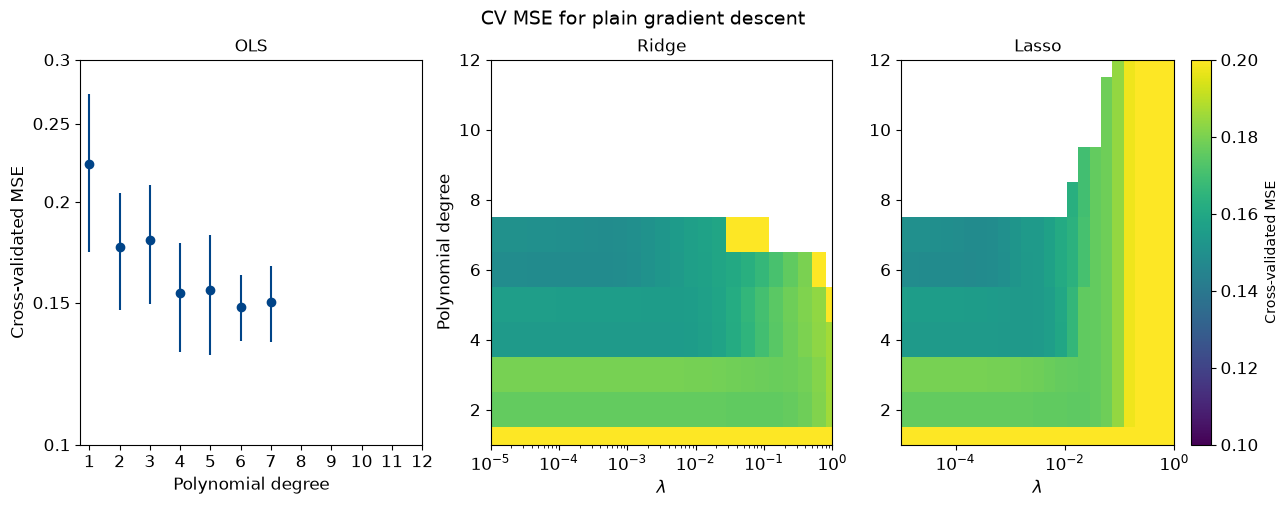

Minimum MSE:  0.14340056792452657  Best degree:  8
Minimum MSE:  0.14466198206745678 Best degree:  10   lambda:  1e-05
Minimum MSE:  0.1435297086259441 Best degree:  8   lambda:  1e-05


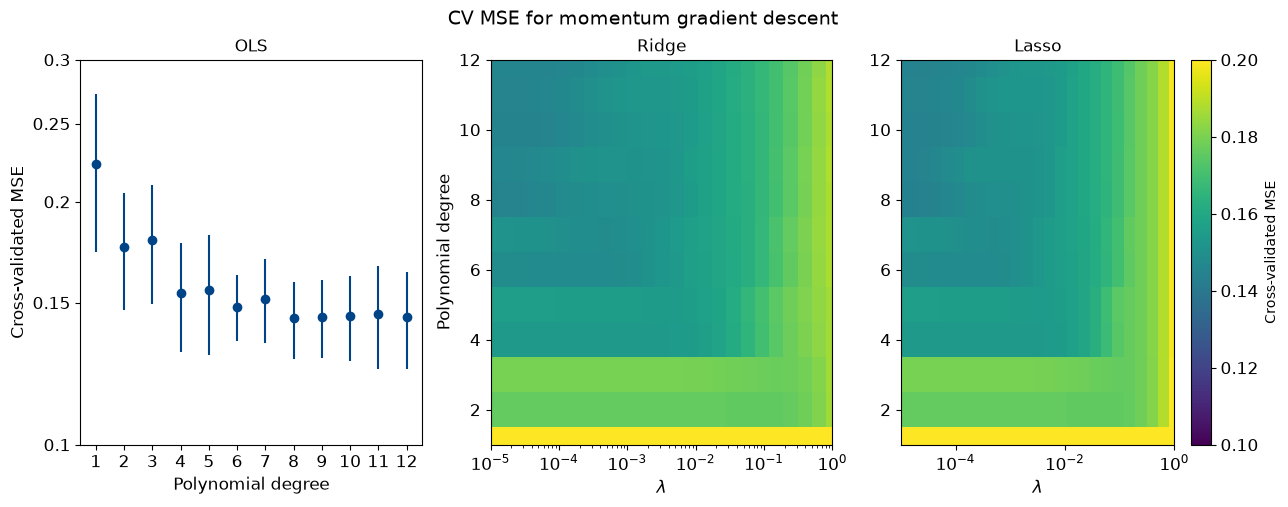

Minimum MSE:  0.1479313858750504  Best degree:  12
Minimum MSE:  0.14766297262417638 Best degree:  6   lambda:  0.0002872984833353666
Minimum MSE:  0.14764617717582862 Best degree:  6   lambda:  0.00011006941712522103


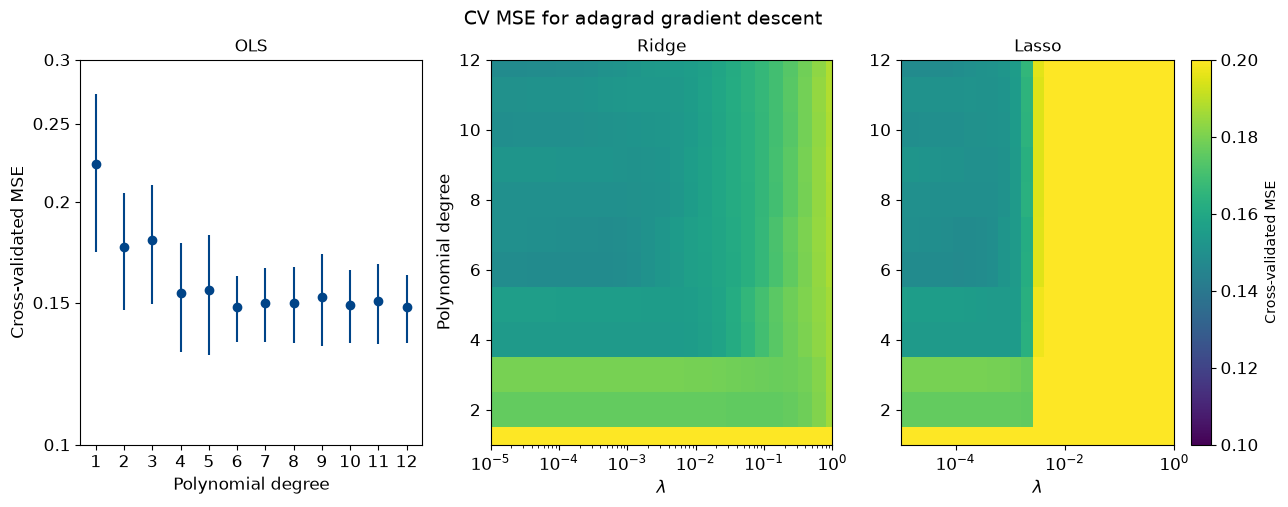

Minimum MSE:  0.22349827337080158  Best degree:  1
Minimum MSE:  0.14437785345787169 Best degree:  6   lambda:  0.0004641588833612782
Minimum MSE:  0.22349827337080158 Best degree:  1   lambda:  1e-05


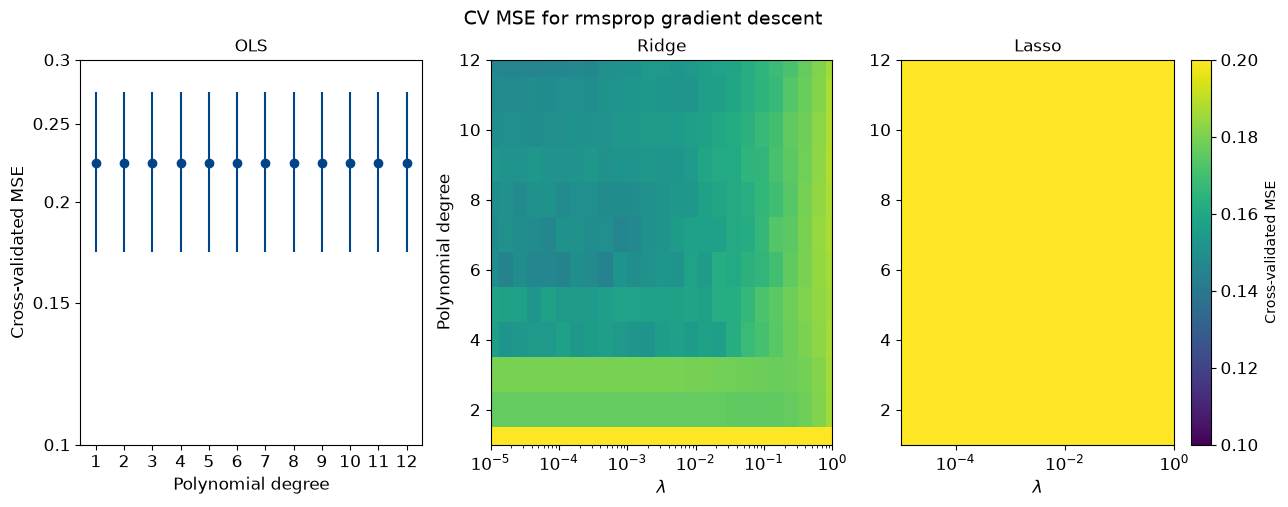

Minimum MSE:  0.14329145507846958  Best degree:  8
Minimum MSE:  0.14326881782604736 Best degree:  10   lambda:  4.216965034285822e-05
Minimum MSE:  0.14341924106457357 Best degree:  8   lambda:  1.6155980984398728e-05


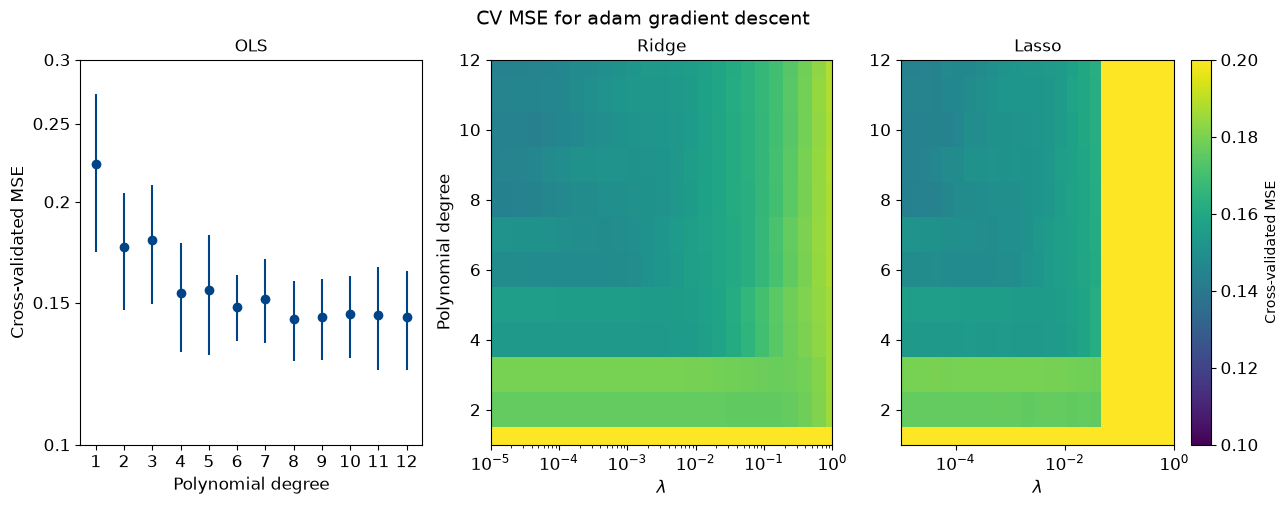

In [22]:
#CV MSE calculation for OLS regression

# From d) own implementation of CV MSE, adjusted to include gradient descent and the different regression methods (OLS, Ridge, Lasso)
def my_kfold_mse(x, y, degree, lmb,gamma, k, method="plain", reg_method="Ridge", seed=2026):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    poly = PolynomialFeatures(degree=degree)
    fold_mse = np.zeros(k)

    for j, (train_idx, test_idx) in enumerate(kf.split(x)):
        x_train, y_train = x[train_idx], y[train_idx]
        x_test,  y_test  = x[test_idx],  y[test_idx]

        X_train = poly.fit_transform(x_train)
        X_test  = poly.transform(x_test)

        scaler = StandardScaler().fit(X_train)
        theta_gd, _, _ = gradient_descent(scaler.transform(X_train), y_train, gamma, lmb, num_iters, tol, method=method, reg_method=reg_method) 

        y_pred = scaler.transform(X_test) @ theta_gd

        fold_mse[j] = np.mean((y_test - y_pred) ** 2)

    return fold_mse.mean(), fold_mse.std()

x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
x_cv = x_cv.reshape(-1, 1)

# Sanity check against cross_val_score, at one (degree, lambda) point
degree_check, lmb_check, k_check = 6, 0.1, 5
mine, mine_std = my_kfold_mse(x_cv, y_cv, degree_check, lmb_check,gamma=optimiser_dict["plain"]["Ridge"], k=k_check)

kf = KFold(n_splits=k_check, shuffle=True, random_state=2026)
pipe = make_pipeline(PolynomialFeatures(degree=degree_check), StandardScaler(), Ridge(alpha=n*lmb_check,fit_intercept=False))
sklearn_mse = -cross_val_score(pipe, x_cv, y_cv, cv=kf, scoring="neg_mean_squared_error").mean()

print(f"GD: {mine:.6f} vs  sklearn: {sklearn_mse:.6f}")


# Input parameterse
degrees = list(range(1, 13))
lambdas = np.logspace(-5, 0, 25)

#Creating empty dictionary to store the best CV results for each method and regression type
CV_dict = {
    "plain": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "momentum": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "adagrad": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "rmsprop": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "adam": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    }
}



# Doing the CV analysis for each method and regression type
for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 

        # If OLS, then we only need to loop over degrees, otherwise we loop over both degrees and lambdas
        if reg_method == "OLS":
            CV_mse = np.zeros(len(degrees))
            CV_std = np.zeros(len(degrees))
                        
            for ii, degree in enumerate(degrees):

                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lmb=0, gamma=optimiser_dict[method][reg_method], k=5,method=method,reg_method=reg_method)
                CV_mse[ii]= mine
                CV_std[ii] = mine_std

        else:
            CV_mse = np.zeros((len(degrees), len(lambdas)))
            for ii, degree in enumerate(degrees):

                for jj, lam in enumerate(lambdas):
                    mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lam, gamma=optimiser_dict[method][reg_method], k=5,method=method,reg_method=reg_method)
                    CV_mse[ii, jj] = mine
                    # CV_std[ii, jj] = mine_std

        if reg_method == "OLS":
            # ax[i].plot(degrees, CV_mse,  "o-", color="#004488", label="CV, k=5")
            ax[i].errorbar(degrees, CV_mse, yerr=CV_std, fmt='o', color="#004488") # capsize=5
            ax[i].set_yscale("log")
            ax[i].set_ylim(1e-1, 3e-1)
            ax[i].set_xlabel("Polynomial degree",fontsize=12)
            ax[i].set_xticks(np.arange(1, 13, 1))
            ax[i].set_xticklabels(np.arange(1, 13, 1), fontsize=12)
            ax[i].set_yticks((0.1,0.15,0.2,0.25,0.3))
            ax[i].set_yticklabels((0.1,0.15,0.2,0.25,0.3), fontsize=12)
            
            print("Minimum MSE: ", np.nanmin(CV_mse), " Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]])
            #Adding the best schedule to the dictionary for each method and batch size
            CV_dict[method][reg_method] = (float(f"{np.nanmin(CV_mse):.4f}"), int(degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]]), np.nan)
        
        else:
            im = ax[i].pcolormesh(lambdas,degrees,CV_mse,vmin=1e-1, vmax=2e-1, label="CV, k=5")
            ax[i].set_xscale("log")
            ax[i].set_xlabel(r"$\lambda$", fontsize=12)
            ax[i].set_ylim(1, 12)
            ax[i].set_xlim(lambdas.min(), lambdas.max())

            print("Minimum MSE: ", np.nanmin(CV_mse), "Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]], "  lambda: ", lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]])
            #Adding the best schedule to the dictionary for each method and batch size
            CV_dict[method][reg_method] = (float(f"{np.nanmin(CV_mse):.4f}"), int(degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]]), float(f"{lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]]:.4f}"))
    
        ax[i].set_title(f"{reg_method}") # CV-MSE, k=5
        ax[i].tick_params(axis='both', labelsize=12)
    
    ax[0].set_ylabel("Cross-validated MSE", fontsize=12)
    ax[1].set_ylabel("Polynomial degree", fontsize=12)
    cbar = fig.colorbar(im, ax=ax[2], label=r"Cross-validated MSE")
    cbar.ax.tick_params(labelsize=12)
    plt.suptitle(f"CV MSE for {method} gradient descent", fontsize=14)
    plt.savefig(f"project1_taski_{method}.png", bbox_inches="tight")
    plt.show()



In [23]:
print(CV_dict)

{'plain': {'OLS': (0.1482, 6, nan), 'Ridge': (0.1477, 6, 0.0003), 'Lasso': (0.1476, 6, 0.0002)}, 'momentum': {'OLS': (0.1434, 8, nan), 'Ridge': (0.1447, 10, 0.0), 'Lasso': (0.1435, 8, 0.0)}, 'adagrad': {'OLS': (0.1479, 12, nan), 'Ridge': (0.1477, 6, 0.0003), 'Lasso': (0.1476, 6, 0.0001)}, 'rmsprop': {'OLS': (0.2235, 1, nan), 'Ridge': (0.1444, 6, 0.0005), 'Lasso': (0.2235, 1, 0.0)}, 'adam': {'OLS': (0.1433, 8, nan), 'Ridge': (0.1433, 10, 0.0), 'Lasso': (0.1434, 8, 0.0)}}


In [24]:
#CV MSE calculation for OLS regression


#Creating empty dictionary to store the best CV results for each method and regression type
CV_dict2 = {
    "plain": {
        "OLS": (0, 0,),
        "Ridge": (0, 0),
        "Lasso": (0, 0)
    },
    "momentum": {
        "OLS": (0, 0),
        "Ridge": (0, 0),
        "Lasso": (0, 0)
    },
    "adagrad": {
        "OLS": (0, 0),
        "Ridge": (0, 0),
        "Lasso": (0, 0)
    },
    "rmsprop": {
        "OLS": (0, 0),
        "Ridge": (0, 0),
        "Lasso": (0, 0)
    },
    "adam": {
        "OLS": (0, 0),
        "Ridge": (0, 0),
        "Lasso": (0, 0)
    }
}


degree=5
# Doing the CV analysis for each method and regression type
for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):

    for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 

        CV_mse, CV_std = my_kfold_mse(x_cv, y_cv, degree, lmb=optimiser_dict["lmbdas"][reg_method], gamma=optimiser_dict[method][reg_method], k=5,method=method,reg_method=reg_method)

        print(reg_method, method, ": MSE:", f"{CV_mse:.4f}", "Standard deviation:", f"{CV_std:.4f}")
        #Adding the best schedule to the dictionary for each method and batch size
        CV_dict2[method][reg_method] = (f"{CV_mse:.4f}", f"{CV_std:.4f}")


OLS plain : MSE: 0.1555 Standard deviation: 0.0262
Ridge plain : MSE: 0.1557 Standard deviation: 0.0234
Lasso plain : MSE: 0.1555 Standard deviation: 0.0262
OLS momentum : MSE: 0.1555 Standard deviation: 0.0262
Ridge momentum : MSE: 0.1557 Standard deviation: 0.0234
Lasso momentum : MSE: 0.1555 Standard deviation: 0.0262
OLS adagrad : MSE: 0.1555 Standard deviation: 0.0262
Ridge adagrad : MSE: 0.1557 Standard deviation: 0.0234
Lasso adagrad : MSE: 0.1555 Standard deviation: 0.0262
OLS rmsprop : MSE: 0.2235 Standard deviation: 0.0500
Ridge rmsprop : MSE: 0.1534 Standard deviation: 0.0246
Lasso rmsprop : MSE: 0.2235 Standard deviation: 0.0500
OLS adam : MSE: 0.1555 Standard deviation: 0.0262
Ridge adam : MSE: 0.1557 Standard deviation: 0.0234
Lasso adam : MSE: 0.1562 Standard deviation: 0.0256


Minimum MSE:  0.14329145507846958  Best degree:  8
Minimum MSE:  0.14326881782604736 Best degree:  10   lambda:  4.216965034285822e-05
Minimum MSE:  0.14341924106457357 Best degree:  8   lambda:  1.6155980984398728e-05


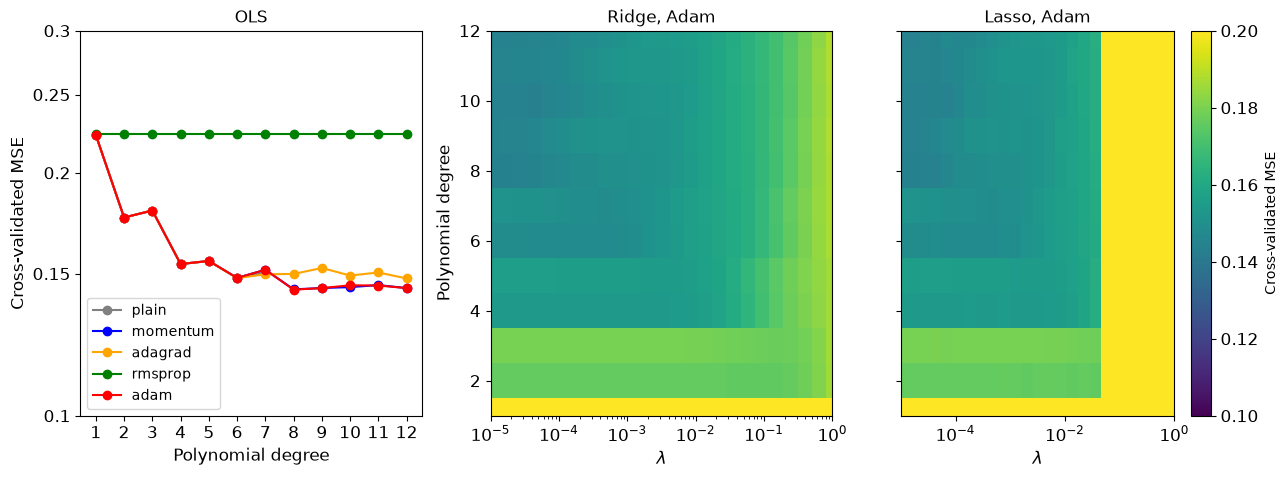

In [25]:

# Doing the CV analysis for each method and regression type
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 
    if reg_method == "OLS":
        for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):

            CV_mse = np.zeros(len(degrees))
            CV_std = np.zeros(len(degrees))
                        
            for ii, degree in enumerate(degrees):

                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lmb=0,gamma=optimiser_dict[method][reg_method], k=5,method=method,reg_method=reg_method)
                CV_mse[ii]= mine
                CV_std[ii] = mine_std

            ax[i].plot(degrees, CV_mse,  "o-", color=optimiser_dict[method]["color"],label=method)
            # ax[i].errorbar(degrees, CV_mse, yerr=CV_std, fmt='o', color=optimiser_dict[method]["color"],label=method) # capsize=5
        
        ax[i].set_yscale("log")
        ax[i].set_ylim(1e-1, 3e-1)
        ax[i].set_xlabel("Polynomial degree",fontsize=12)
        ax[i].set_xticks(np.arange(1, 13, 1))
        ax[i].set_xticklabels(np.arange(1, 13, 1), fontsize=12)
        ax[i].set_yticks((0.1,0.15,0.2,0.25,0.3))
        ax[i].set_yticklabels((0.1,0.15,0.2,0.25,0.3), fontsize=12)
        ax[i].set_title(f"{reg_method}") 
        ax[i].legend(fontsize=10)
        print("Minimum MSE: ", CV_mse.min(), " Best degree: ", degrees[np.where(CV_mse == CV_mse.min())[0][0]])

    
    else: #Only look at Adam for Ridge and Lasso
        method = "adam"
        CV_mse = np.zeros((len(degrees), len(lambdas)))
        for ii, degree in enumerate(degrees):

            for jj, lam in enumerate(lambdas):
                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lam,gamma=optimiser_dict[method][reg_method], k=5,method=method,reg_method=reg_method)
                CV_mse[ii, jj] = mine

    
        im = ax[i].pcolormesh(lambdas,degrees,CV_mse,vmin=1e-1, vmax=2e-1)
        ax[i].set_xscale("log")
        ax[i].set_xlabel(r"$\lambda$", fontsize=12)
        ax[i].set_ylim(1, 12)
        ax[i].set_xlim(lambdas.min(), lambdas.max())

        print("Minimum MSE: ", np.nanmin(CV_mse), "Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]], "  lambda: ", lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]])

        ax[i].set_title(f"{reg_method}, Adam") 
    
    ax[i].tick_params(axis='both', labelsize=12)

ax[0].set_ylabel("Cross-validated MSE", fontsize=12)
ax[1].set_ylabel("Polynomial degree", fontsize=12)
ax[2].set_yticklabels(())
cbar = fig.colorbar(im, ax=ax[2], label=r"Cross-validated MSE")
cbar.ax.tick_params(labelsize=12)

plt.savefig(f"project1_taski_allmethods.png", bbox_inches="tight")
plt.show()


Minimum MSE:  0.14795011478190592  Best degree:  6
Minimum MSE:  0.14770630546710922 Best degree:  6   lambda:  0.0002872984833353666
Minimum MSE:  0.14769416163935317 Best degree:  6   lambda:  6.812920690579608e-05


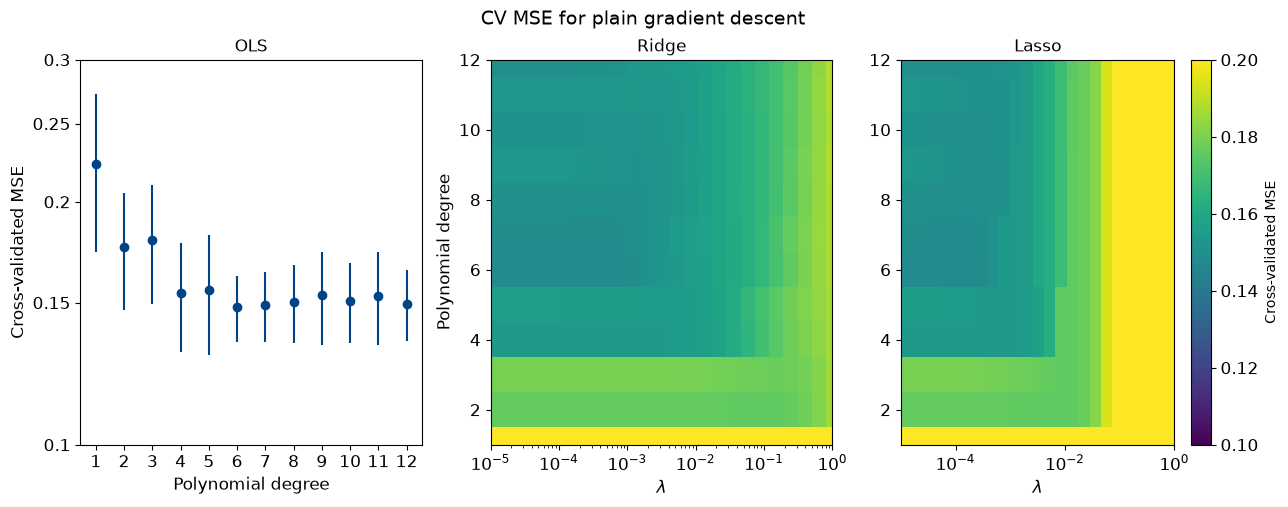

Minimum MSE:  0.14460867034644398  Best degree:  8
Minimum MSE:  0.14466198206745678 Best degree:  10   lambda:  1e-05
Minimum MSE:  0.14464109413466375 Best degree:  10   lambda:  1e-05


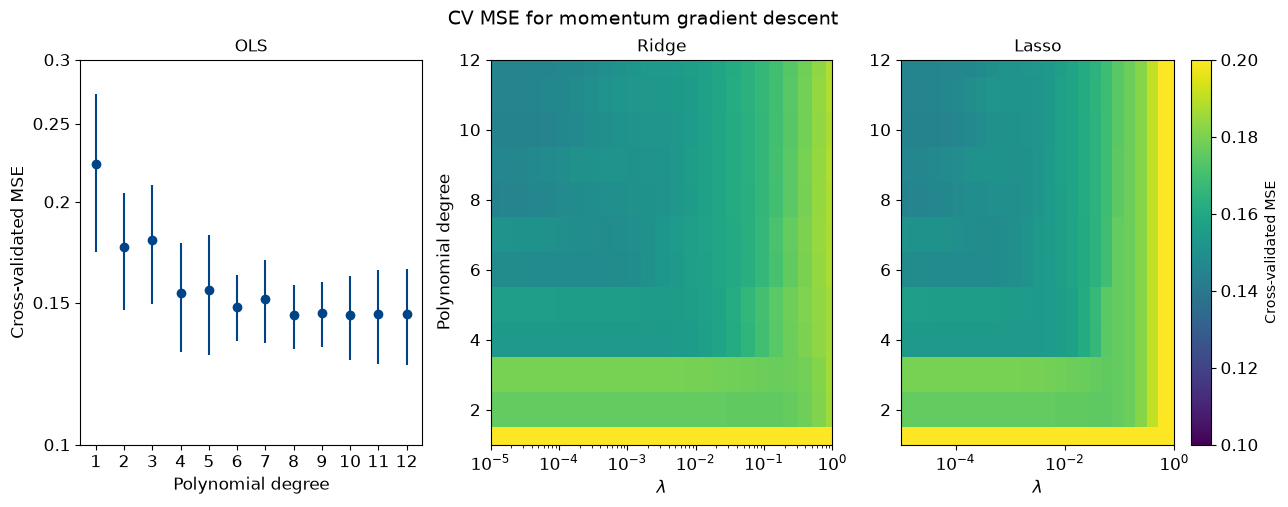

Minimum MSE:  0.14788821875145403  Best degree:  12
Minimum MSE:  0.14766297262417638 Best degree:  6   lambda:  0.0002872984833353666
Minimum MSE:  0.14759786443654738 Best degree:  6   lambda:  0.00017782794100389227


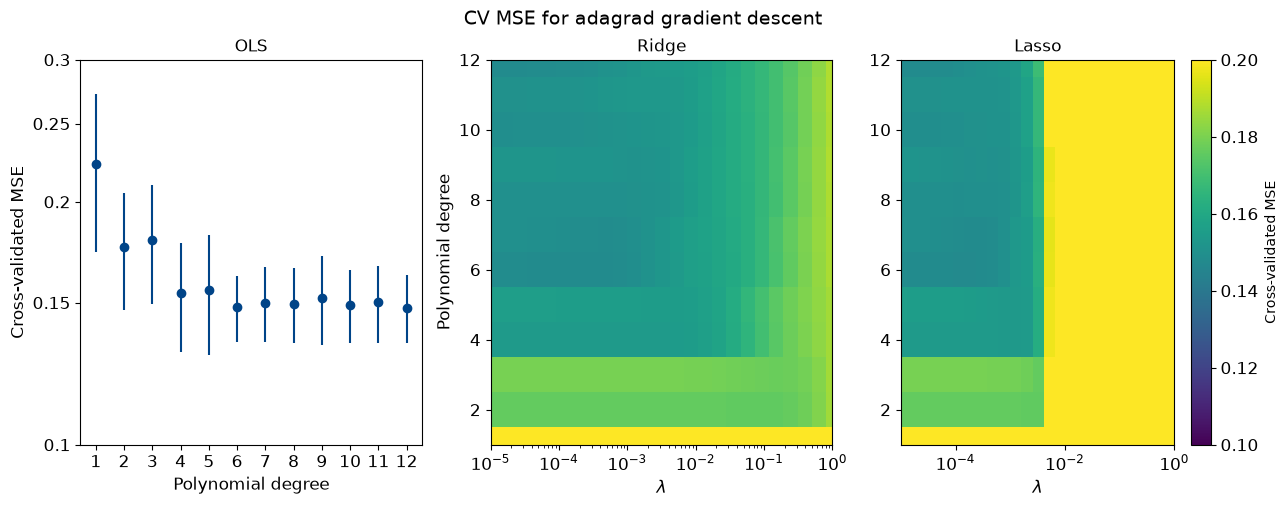

Minimum MSE:  0.15905370173412825  Best degree:  7
Minimum MSE:  0.1459581046826146 Best degree:  4   lambda:  0.0007498942093324559
Minimum MSE:  0.14490305237810577 Best degree:  7   lambda:  0.0019573417814876615


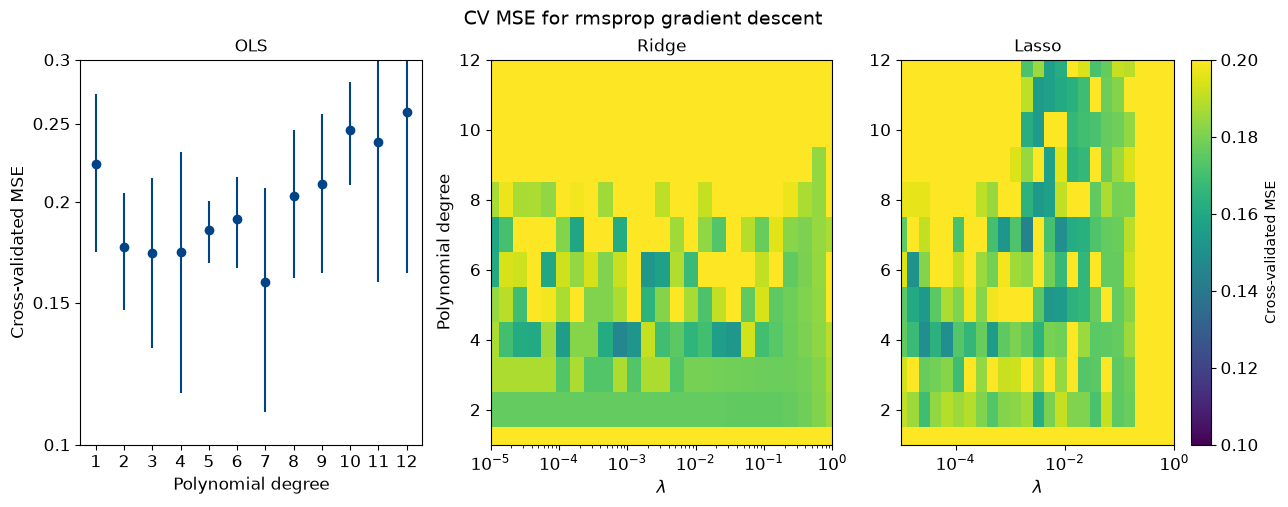

Minimum MSE:  0.14325903646287652  Best degree:  8
Minimum MSE:  0.14337154611720285 Best degree:  10   lambda:  4.216965034285822e-05
Minimum MSE:  0.14300169663728904 Best degree:  8   lambda:  1.6155980984398728e-05


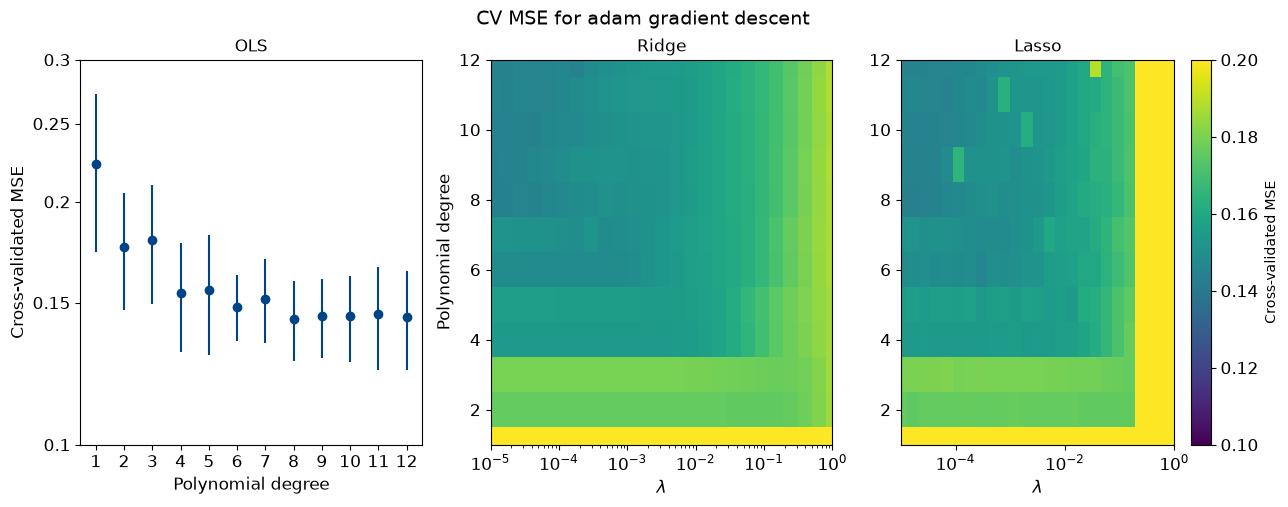

Minimum MSE:  0.14325903646287652  Best degree:  8
Minimum MSE:  0.14337154611720285 Best degree:  10   lambda:  4.216965034285822e-05
Minimum MSE:  0.14300169663728904 Best degree:  8   lambda:  1.6155980984398728e-05


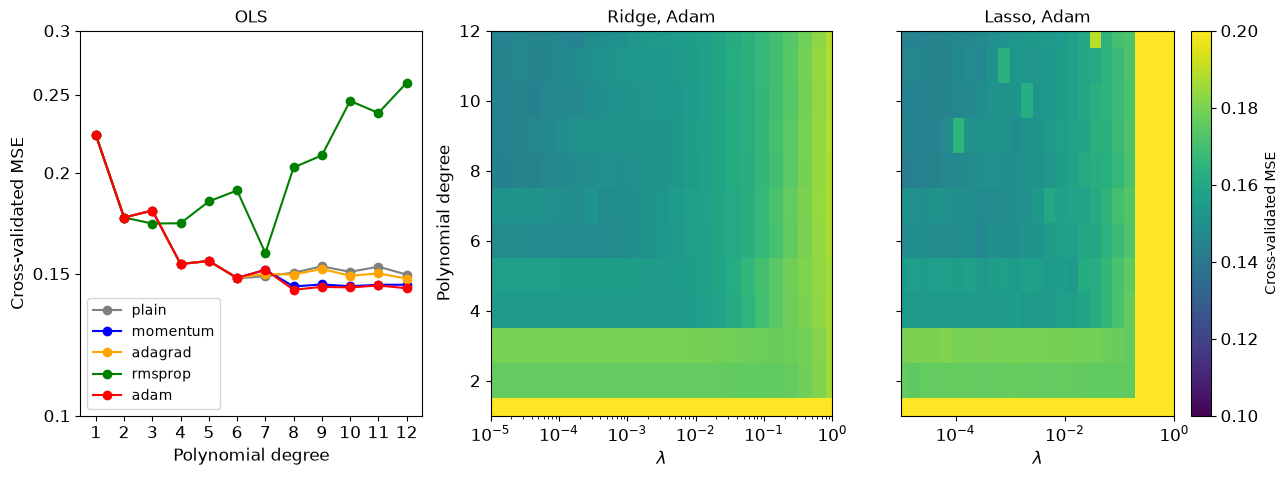

In [26]:
#CV MSE calculation for OLS regression

# Input parameterse
degrees = list(range(1, 13))
lambdas = np.logspace(-5, 0, 25)

gamma = 0.1

#Creating empty dictionary to store the best CV results for each method and regression type
CV_constgamma = {
    "plain": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "momentum": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "adagrad": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "rmsprop": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    },
    "adam": {
        "OLS": (0, 0, 0),
        "Ridge": (0, 0, 0),
        "Lasso": (0, 0, 0)
    }
}



# Doing the CV analysis for each method and regression type
for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 

        # If OLS, then we only need to loop over degrees, otherwise we loop over both degrees and lambdas
        if reg_method == "OLS":
            CV_mse = np.zeros(len(degrees))
            CV_std = np.zeros(len(degrees))
                        
            for ii, degree in enumerate(degrees):

                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lmb=0, gamma=gamma, k=5,method=method,reg_method=reg_method)
                CV_mse[ii]= mine
                CV_std[ii] = mine_std

        else:
            CV_mse = np.zeros((len(degrees), len(lambdas)))
            for ii, degree in enumerate(degrees):

                for jj, lam in enumerate(lambdas):
                    mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lam, gamma=gamma, k=5,method=method,reg_method=reg_method)
                    CV_mse[ii, jj] = mine
                    # CV_std[ii, jj] = mine_std

        if reg_method == "OLS":
            # ax[i].plot(degrees, CV_mse,  "o-", color="#004488", label="CV, k=5")
            ax[i].errorbar(degrees, CV_mse, yerr=CV_std, fmt='o', color="#004488") # capsize=5
            ax[i].set_yscale("log")
            ax[i].set_ylim(1e-1, 3e-1)
            ax[i].set_xlabel("Polynomial degree",fontsize=12)
            ax[i].set_xticks(np.arange(1, 13, 1))
            ax[i].set_xticklabels(np.arange(1, 13, 1), fontsize=12)
            ax[i].set_yticks((0.1,0.15,0.2,0.25,0.3))
            ax[i].set_yticklabels((0.1,0.15,0.2,0.25,0.3), fontsize=12)
            
            print("Minimum MSE: ", np.nanmin(CV_mse), " Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]])
            #Adding the best schedule to the dictionary for each method and batch size
            CV_constgamma[method][reg_method] = (float(f"{np.nanmin(CV_mse):.4f}"), int(degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]]), np.nan)
        
        else:
            im = ax[i].pcolormesh(lambdas,degrees,CV_mse,vmin=1e-1, vmax=2e-1, label="CV, k=5")
            ax[i].set_xscale("log")
            ax[i].set_xlabel(r"$\lambda$", fontsize=12)
            ax[i].set_ylim(1, 12)
            ax[i].set_xlim(lambdas.min(), lambdas.max())

            print("Minimum MSE: ", np.nanmin(CV_mse), "Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]], "  lambda: ", lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]])
            #Adding the best schedule to the dictionary for each method and batch size
            CV_constgamma[method][reg_method] = (float(f"{np.nanmin(CV_mse):.4f}"), int(degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]]), float(f"{lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]]:.4f}"))
    
        ax[i].set_title(f"{reg_method}")
        ax[i].tick_params(axis='both', labelsize=12)
    
    ax[0].set_ylabel("Cross-validated MSE", fontsize=12)
    ax[1].set_ylabel("Polynomial degree", fontsize=12)
    cbar = fig.colorbar(im, ax=ax[2], label=r"Cross-validated MSE")
    cbar.ax.tick_params(labelsize=12)
    plt.suptitle(f"CV MSE for {method} gradient descent", fontsize=14)
    plt.savefig(f"project1_taski_{method}_constgamma.png", bbox_inches="tight")
    plt.show()





# Doing the CV analysis for each method and regression type
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 
    if reg_method == "OLS":
        for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):

            CV_mse = np.zeros(len(degrees))
            CV_std = np.zeros(len(degrees))
                        
            for ii, degree in enumerate(degrees):

                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lmb=0,gamma=gamma, k=5,method=method,reg_method=reg_method)
                CV_mse[ii]= mine
                CV_std[ii] = mine_std

            ax[i].plot(degrees, CV_mse,  "o-", color=optimiser_dict[method]["color"],label=method)
            # ax[i].errorbar(degrees, CV_mse, yerr=CV_std, fmt='o', color=optimiser_dict[method]["color"],label=method) # capsize=5
        
        ax[i].set_yscale("log")
        ax[i].set_ylim(1e-1, 3e-1)
        ax[i].set_xlabel("Polynomial degree",fontsize=12)
        ax[i].set_xticks(np.arange(1, 13, 1))
        ax[i].set_xticklabels(np.arange(1, 13, 1), fontsize=12)
        ax[i].set_yticks((0.1,0.15,0.2,0.25,0.3))
        ax[i].set_yticklabels((0.1,0.15,0.2,0.25,0.3), fontsize=12)
        ax[i].set_title(f"{reg_method}") 
        ax[i].legend(fontsize=10)
        print("Minimum MSE: ", CV_mse.min(), " Best degree: ", degrees[np.where(CV_mse == CV_mse.min())[0][0]])

    
    else: #Only look at Adam for Ridge and Lasso
        method = "adam"
        CV_mse = np.zeros((len(degrees), len(lambdas)))
        for ii, degree in enumerate(degrees):

            for jj, lam in enumerate(lambdas):
                mine, mine_std = my_kfold_mse(x_cv, y_cv, degree, lam,gamma=gamma, k=5,method=method,reg_method=reg_method)
                CV_mse[ii, jj] = mine

    
        im = ax[i].pcolormesh(lambdas,degrees,CV_mse,vmin=1e-1, vmax=2e-1)
        ax[i].set_xscale("log")
        ax[i].set_xlabel(r"$\lambda$", fontsize=12)
        ax[i].set_ylim(1, 12)
        ax[i].set_xlim(lambdas.min(), lambdas.max())

        print("Minimum MSE: ", np.nanmin(CV_mse), "Best degree: ", degrees[np.where(CV_mse == np.nanmin(CV_mse))[0][0]], "  lambda: ", lambdas[np.where(CV_mse == np.nanmin(CV_mse))[1][0]])

        ax[i].set_title(f"{reg_method}, Adam") 
    
    ax[i].tick_params(axis='both', labelsize=12)

ax[0].set_ylabel("Cross-validated MSE", fontsize=12)
ax[1].set_ylabel("Polynomial degree", fontsize=12)
ax[2].set_yticklabels(())
cbar = fig.colorbar(im, ax=ax[2], label=r"Cross-validated MSE")
cbar.ax.tick_params(labelsize=12)

plt.savefig(f"project1_taski_allmethods_constgamma.png", bbox_inches="tight")
plt.show()

